# `vectorEngine` - The geospatial processing engine for vector data

In this tutorial, we will explore the functionality contained within the `vectorEngine` at the second level of the software architecture hierarchy of the `bmc` library. Inheriting directly from `baseGrid` and serving as the parent class to the `vectorCube` orchestrator, this engine acts as the universal spatial toolbox for vector data.

The class serves as a central hub to aggregate all geospatial methods needed to perform the harmonization of vector data. Crucially, it is completely decoupled from data lifecycle management (like downloading or cataloging), focusing exclusively on physical spatial transformations such as converting raw tabular coordinates into valid geometries and healing dirty topologies. By leveraging memory-efficient batched processing and fast `KDTree` spatial queries, the engine safely executes heavy operations—like polygon shattering and fractional intersections—on massive datasets without exceeding memory limits. It also acts as the gatekeeper for spatial and topological validity, managing coordinate uncertainty through probabilistic Monte Carlo point clouds and ensuring that all vector geometries align perfectly onto mathematically rigid master grid templates.

```mermaid
classDiagram
    direction TB

    class baseGrid {
        <<Parent>>
        +dict GRID_REGISTRY
        +resolve_grid_registry_key()
        +build_safe_fetch_envelope()
        +create_aligned_raster_template()
        +calculate_deterministic_global_indices()
    }

    class vectorEngine {
        <<Core Engine>>
        +coordinate_to_geometry()
        +sanitize_geometries()
        +generate_spatial_point_clouds()
        +map_points_to_template()
        +map_point_cloud_to_template()
        +map_polygon_to_template()
        +map_cellCollection_to_template()
        +validate_vector_transformation()
    }

    class vectorCube {
        <<High-Level Orchestrator>>
        +fetch_vector_by_bbox()
        +fetch_data()
        +resolve_target_grid()
        +_apply_cf_temporal_standards()
        +process_cube()
        +aggregate_vector_cube()
        +generate_vector_stac_item()
    }

    %% Inheritance relationships
    baseGrid <|-- vectorEngine : Inherits
    vectorEngine <|-- vectorCube : Inherits

In [1]:
from bmc.engine.vector import vectorEngine
import pandas as pd
import geopandas as gpd
import shapely
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
import numpy as np

# Methods of the vector engine

## Geometry sanitization

## Vector Data Sanitization and Validation

When processing spatial data from diverse sources, the inputs are often messy, corrupted, or misaligned. The `vectorEngine` provides a robust suite of helper functions to guarantee that only mathematically valid, topologically sound, and correctly projected geometries enter the processing pipeline. 

Below is a detailed breakdown of the three primary sanitization and validation functions within the engine.

### `_validate_geom_column`
Before any heavy geometric transformations begin, the engine must ensure the data structure itself is sound. `_validate_geom_column` performs shared precondition checks to guarantee column existence, non-emptiness, and strict geometry type constraints. 

Specifically, this function:
*   Verifies that the target geometry column actually exists in the GeoDataFrame.
*   Checks for and raises a `ValueError` if any null or empty geometries are found within the column.
*   Extracts the unique geometry types present in the dataset and ensures they strictly conform to a provided set of `allowed_types`.

### `_ensure_crs`
Spatial alignment is impossible if datasets exist in conflicting coordinate reference systems. `_ensure_crs` validates the CRS of an incoming GeoDataFrame against an expected target CRS.

*   If the input GeoDataFrame lacks a defined CRS entirely, it raises a `ValueError` to prevent blind, unsafe geometric mapping.
*   It compares the source CRS against the target CRS and safely reprojects the data only if a mismatch is detected, preventing unnecessary computational overhead.



### `sanitize_geometries`

This is the core healing mechanism of the vector engine. Real-world vector data frequently contains self-intersecting polygons, 3D coordinates mixed with 2D coordinates, or accidental `GeometryCollection` objects. `sanitize_geometries` cleans, flattens, normalizes, and validates these dirty vector geometries.

The sanitization pipeline executes several critical steps:
*   **Purging Nulls:** It removes any rows where the geometry is null or empty.
*   **Dimensionality Normalization:** It forces all geometries into a 2D planar space using `shapely.force_2d`.
*   **Topology Healing:** It identifies topologically invalid geometries and repairs them using `shapely.make_valid`.
*   **Collection Flattening:** If the healing process results in a `GeometryCollection`, it dynamically parses the collection to extract and reconstruct standard MultiPolygons, MultiLineStrings, or MultiPoints.
*   **Type Homogenization:** If `force_multi=True`, it normalizes atomic geometries (like `Point` or `Polygon`) into their `Multi*` counterparts to ensure a consistent schema.
*   **Deduplication and Filtering:** It can optionally remove exact geometric duplicates and filter the final output to only include user-defined `allowed_types`.

#### Example: Cleaning a Messy Dataset with `sanitize_geometries`

In [2]:
engine = vectorEngine()

# Create a "Dirty" Dummy Dataset
# - Valid Polygon
valid_poly = Polygon([(0, 0), (0, 2), (2, 2), (2, 0), (0, 0)])

# - Invalid Polygon (A "Bow-tie" self-intersection)
invalid_poly = Polygon([(0, 0), (2, 2), (0, 2), (2, 0), (0, 0)])

# - 3D Point (Needs to be forced to 2D)
point_3d = Point(1, 1, 100)

# - Empty Geometry (Needs to be purged)
empty_geom = Polygon()

# - Null Geometry (Needs to be purged)
null_geom = None

# Build the raw GeoDataFrame
messy_gdf = gpd.GeoDataFrame({
    'id': [1, 2, 3, 4, 5],
    'description': ['Valid Poly', 'Invalid Bowtie', '3D Point', 'Empty Geom', 'Null Geom']
}, geometry=[valid_poly, invalid_poly, point_3d, empty_geom, null_geom], crs="EPSG:4326")

print("--- RAW MESSY DATASET ---")
print(messy_gdf)
print(f"\nAre geometries valid? \n{messy_gdf.geometry.is_valid}")

# Sanitize the Geometries
# We will enforce homogenization to Multi-geometries and filter out points.
clean_gdf = engine.sanitize_geometries(
    gdf=messy_gdf,
    allowed_types=["MultiPolygon"],
    force_multi=True,
    deduplicate=False
)

print("\n--- SANITIZED DATASET ---")
print(clean_gdf)
print(f"\nAre geometries valid? \n{clean_gdf.geometry.is_valid}")
print(f"\nFinal Geometry Types: \n{clean_gdf.geom_type}")

--- RAW MESSY DATASET ---
   id     description                             geometry
0   1      Valid Poly  POLYGON ((0 0, 0 2, 2 2, 2 0, 0 0))
1   2  Invalid Bowtie  POLYGON ((0 0, 2 2, 0 2, 2 0, 0 0))
2   3        3D Point                    POINT Z (1 1 100)
3   4      Empty Geom                        POLYGON EMPTY
4   5       Null Geom                                 None

Are geometries valid? 
0     True
1    False
2     True
3     True
4    False
dtype: bool

--- SANITIZED DATASET ---
   id     description                                           geometry
0   1      Valid Poly         MULTIPOLYGON (((0 0, 0 2, 2 2, 2 0, 0 0)))
1   2  Invalid Bowtie  MULTIPOLYGON (((2 0, 0 0, 1 1, 2 0)), ((2 2, 1...

Are geometries valid? 
0    True
1    True
dtype: bool

Final Geometry Types: 
0    MultiPolygon
1    MultiPolygon
dtype: str


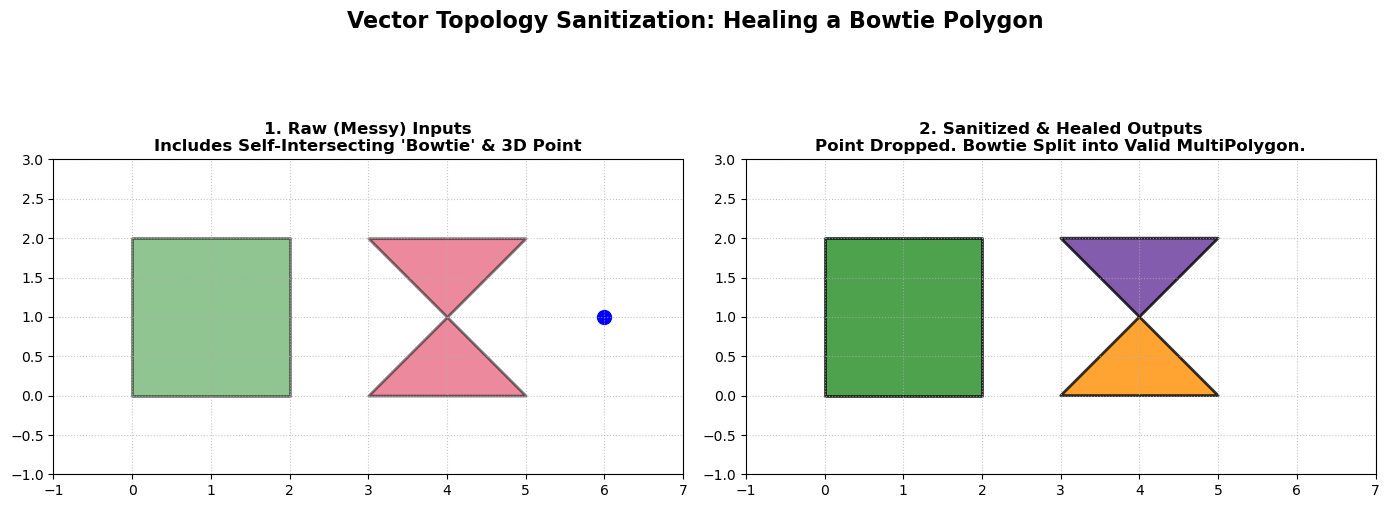

In [3]:
# Shifted along the X-axis so they don't overlap visually
valid_poly = Polygon([(0, 0), (0, 2), (2, 2), (2, 0), (0, 0)])
invalid_poly = Polygon([(3, 0), (5, 2), (3, 2), (5, 0), (3, 0)]) # The Bowtie
point_3d = Point(6, 1, 100)
empty_geom = Polygon()
null_geom = None

messy_gdf = gpd.GeoDataFrame({
    'id': [1, 2, 3, 4, 5],
    'description': ['Valid Poly', 'Invalid Bowtie', '3D Point', 'Empty', 'Null']
}, geometry=[valid_poly, invalid_poly, point_3d, empty_geom, null_geom], crs="EPSG:4326")


# --- Sanitize the Geometries ---
clean_gdf = engine.sanitize_geometries(
    gdf=messy_gdf,
    allowed_types=["MultiPolygon"], # This will intentionally drop the 3D point
    force_multi=True,               # Forces Polygon to MultiPolygon
    deduplicate=False
)


# --- Prepare Data for Plotting ---
# To color the two halves of the healed bowtie differently, we need to "explode" 
# the MultiPolygons into individual rows just for the matplotlib renderer.
plot_gdf = clean_gdf.explode(index_parts=True).reset_index()

# Row 0 will be the original valid polygon. 
# Row 1 and Row 2 will be the newly separated triangles of the bowtie.
colors = ['forestgreen', 'darkorange', 'rebeccapurple']


# --- Plot the Before & After ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.suptitle("Vector Topology Sanitization: Healing a Bowtie Polygon", fontsize=16, fontweight='bold')

# PANEL 1: Raw (Messy) Inputs
# Plotting individually to handle mixed geometry types safely in older Matplotlib versions
gpd.GeoSeries([valid_poly]).plot(ax=axes[0], color='forestgreen', alpha=0.5, edgecolor='black', linewidth=2)
gpd.GeoSeries([invalid_poly]).plot(ax=axes[0], color='crimson', alpha=0.5, edgecolor='black', linewidth=2)
gpd.GeoSeries([point_3d]).plot(ax=axes[0], color='blue', marker='o', markersize=100)

axes[0].set_title("1. Raw (Messy) Inputs\nIncludes Self-Intersecting 'Bowtie' & 3D Point", fontweight='bold')
axes[0].set_aspect('equal')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].set_xlim(-1, 7)
axes[0].set_ylim(-1, 3)

# PANEL 2: Sanitized Outputs
plot_gdf.plot(ax=axes[1], color=colors, alpha=0.8, edgecolor='black', linewidth=2)

axes[1].set_title("2. Sanitized & Healed Outputs\nPoint Dropped. Bowtie Split into Valid MultiPolygon.", fontweight='bold')
axes[1].set_aspect('equal')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].set_xlim(-1, 7)
axes[1].set_ylim(-1, 3)

plt.tight_layout()
plt.show()

## Monte Carlo point cloud generation

### `generate_spatial_point_clouds`

In ecological and historical datasets, coordinates often come with a margin of error (e.g., a GPS point with a 250-meter uncertainty radius). Instead of applying a rigid geometric buffer—which treats every location inside the circle as equally likely and heavily overestimates the presence of an observation—the `vectorEngine` provides a probabilistic Monte Carlo approach.

The `generate_spatial_point_clouds` method creates a cluster of points around the original centroid. When these clouds are later intersected with the master grid, the engine can accurately calculate the fractional probability that the observation fell into a specific cell.

The engine supports two primary distributions:
1.  **Uniform:** Assumes the true location has an equal probability of being anywhere within the uncertainty radius.
2.  **Gaussian (Normal):** Assumes the true location is most likely near the recorded centroid, with the probability tapering off towards the edges of the uncertainty radius.


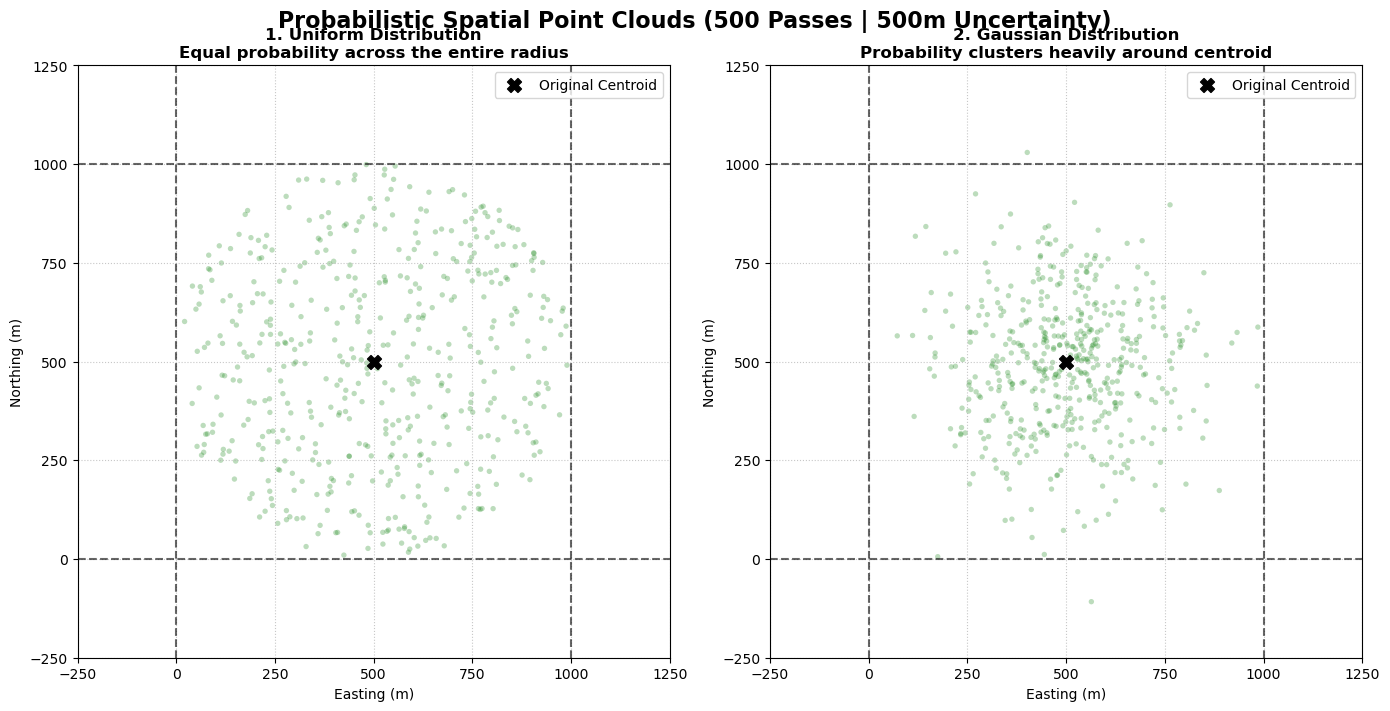

In [4]:
# Setup the Scenarios
# We will use a localized metric projection (EPSG:3035) to make distances clear.
# Let's pretend we have a 1000m x 1000m grid.
point_center = Point(500, 500)    # Scenario A: Center of the cell

gdf = gpd.GeoDataFrame({
    'id': ['A_Center'],
    'coordinateuncertaintyinmeters': [500.0] # Increased to 500m uncertainty
}, geometry=[point_center], crs="EPSG:3035")


# Generate the Point Clouds (500 passes)
# Uniform Distribution
uniform_gdf = engine.generate_spatial_point_clouds(
    gdf=gdf,
    n_passes=500, # Increased passes to clearly show density
    uncertainty_col="coordinateuncertaintyinmeters",
    output_col="point_cloud",
    distribution="uniform",
    random_state=42 # Set seed for reproducible plots
)

# Gaussian Distribution
gaussian_gdf = engine.generate_spatial_point_clouds(
    gdf=gdf,
    n_passes=500,
    uncertainty_col="coordinateuncertaintyinmeters",
    output_col="point_cloud",
    distribution="gaussian",
    random_state=42
)


# Visualization Setup
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
plt.suptitle("Probabilistic Spatial Point Clouds (500 Passes | 500m Uncertainty)", fontsize=16, fontweight='bold')

def plot_cloud(ax, multipoint, color):
    """Helper to extract and plot individual points from the MultiPoint object."""
    x = [p.x for p in multipoint.geoms]
    y = [p.y for p in multipoint.geoms]
    # Removed edge colors and lowered alpha to visualize dense overlaps better
    ax.scatter(x, y, color=color, alpha=0.3, s=15, edgecolor='none')

# Setup Grid Lines to illustrate the cell boundaries
for ax in axes:
    ax.set_aspect('equal')
    # Adjusted limits to center the 1km box beautifully
    ax.set_xlim(-200, 1200)
    ax.set_ylim(-200, 1200)
    
    # Emphasize the 1km grid cell boundaries
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.axvline(x=1000, color='black', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.axhline(y=1000, color='black', linestyle='--', alpha=0.6, linewidth=1.5)
    
    # Add a standard coordinate grid for better distance readability
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.set_xticks(np.arange(-250, 1251, 250))
    ax.set_yticks(np.arange(-250, 1251, 250))
    
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

# PANEL 1: Uniform Distribution
axes[0].set_title("1. Uniform Distribution\nEqual probability across the entire radius", fontweight='bold')
plot_cloud(axes[0], uniform_gdf.loc[0, 'point_cloud'], 'forestgreen') # Center
# Plot original centroid
gdf.plot(ax=axes[0], color='black', marker='X', markersize=100, zorder=5, label='Original Centroid')
axes[0].legend(loc='upper right')

# PANEL 2: Gaussian Distribution
axes[1].set_title("2. Gaussian Distribution\nProbability clusters heavily around centroid", fontweight='bold')
plot_cloud(axes[1], gaussian_gdf.loc[0, 'point_cloud'], 'forestgreen') # Center
# Plot original centroid
gdf.plot(ax=axes[1], color='black', marker='X', markersize=100, zorder=5, label='Original Centroid')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## coordinate to geometry conversion

`coordinate_to_geometry` is a method that is specifically designed to convert a dataframe containing geospatial data into a geopandas table where this data is converted into geometry data. It allows the user to pass tables and the name of the spatial dimensions of that table which will then be used to construct the geopandas dataframe.

Crucially, this function goes beyond simply creating 2D points. It actively manages spatial uncertainty by offering three distinct output topologies based on the `output_type` parameter:

*   **`point`:** Generates standard 2D point geometries.
*   **`polygon`:** Converts points into circular polygons by applying a geometric buffer equal to the coordinate uncertainty radius in meters. If the input is in a geographic coordinate system (like WGS84), the engine intelligently maps the elements into local UTM zones prior to buffering to ensure mathematically accurate metric circles, then projects them back.
*   **`point_cloud`:** Defers to the `generate_spatial_point_clouds` method to create probabilistic Monte Carlo clusters based on the uncertainty.

In [5]:
raw_data = {
    'obs_id': ['1. Center', '2. Boundary', '3. 4-Way Corner', '4. Offset Spill'],
    'x': [500, 1000, 1000, 900],
    'y': [500, 500, 1000, 500],
    'uncertainty': [100.0, 300.0, 700.0, 1000.0]
}
df = pd.DataFrame(raw_data)

# A. Exact Points
points_gdf = engine.coordinate_to_geometry(
    df, x_col='x', y_col='y', output_type='point', input_crs='EPSG:3035'
)

# B. Buffered Polygons
polygons_gdf = engine.coordinate_to_geometry(
    df, x_col='x', y_col='y', uncert_col='uncertainty', 
    output_type='polygon', input_crs='EPSG:3035', quad_segs=16
)

# C. Uniform Point Cloud (100 passes)
clouds_uni_gdf = engine.coordinate_to_geometry(
    df, x_col='x', y_col='y', uncert_col='uncertainty', 
    output_type='point_cloud', input_crs='EPSG:3035',
    point_cloud_config={'distribution': 'uniform', 'n_passes': 200, 'random_state': 43}
)

# D. Gaussian Point Cloud (100 passes)
clouds_gauss_gdf = engine.coordinate_to_geometry(
    df, x_col='x', y_col='y', uncert_col='uncertainty', 
    output_type='point_cloud', input_crs='EPSG:3035',
    point_cloud_config={'distribution': 'gaussian', 'n_passes': 200, 'random_state': 43}
)

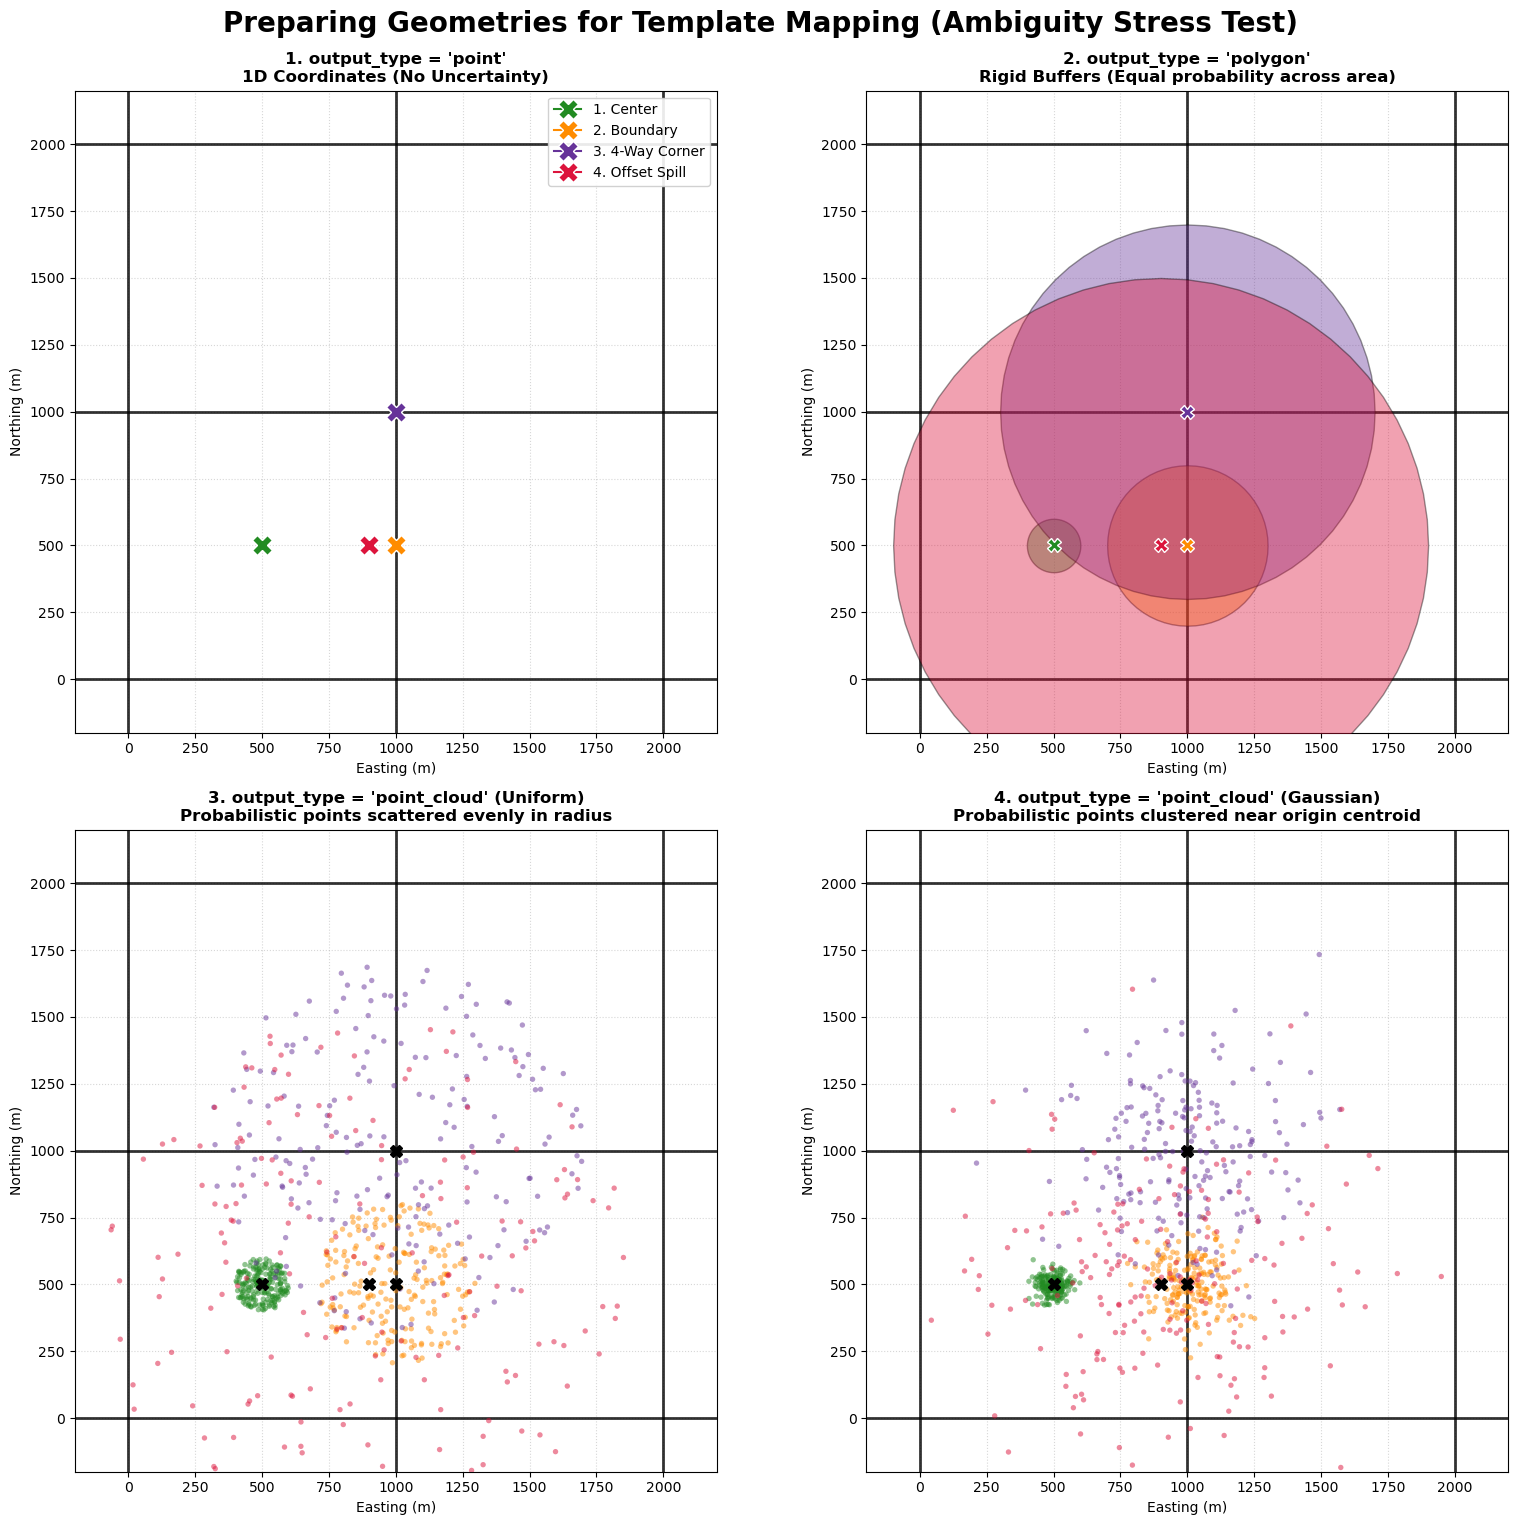

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
plt.suptitle("Preparing Geometries for Template Mapping (Ambiguity Stress Test)", fontsize=20, fontweight='bold', y=0.95)

colors = ['forestgreen', 'darkorange', 'rebeccapurple', 'crimson']

def draw_master_grid(ax):
    """Draws a mock 2x2 grid of 1000m cells for visual mapping context."""
    ax.set_aspect('equal')
    ax.set_xlim(-200, 2200)
    ax.set_ylim(-200, 2200)
    for x in [0, 1000, 2000]:
        ax.axvline(x=x, color='black', linestyle='-', alpha=0.8, linewidth=2)
    for y in [0, 1000, 2000]:
        ax.axhline(y=y, color='black', linestyle='-', alpha=0.8, linewidth=2)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xticks(np.arange(0, 2001, 250))
    ax.set_yticks(np.arange(0, 2001, 250))
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

def plot_cloud(ax, multipoint, color):
    """Helper to extract and plot individual points from a MultiPoint object."""
    x_coords = [p.x for p in multipoint.geoms]
    y_coords = [p.y for p in multipoint.geoms]
    ax.scatter(x_coords, y_coords, color=color, alpha=0.5, s=15, edgecolor='none', zorder=3)

# PANEL A: Exact Points
ax = axes[0, 0]
draw_master_grid(ax)
ax.set_title("1. output_type = 'point'\n1D Coordinates (No Uncertainty)", fontweight='bold')
for idx, row in points_gdf.iterrows():
    ax.plot(row.geometry.x, row.geometry.y, marker='X', color=colors[idx], markersize=14, label=row['obs_id'], markeredgecolor='white', zorder=5)
ax.legend(loc='upper right', framealpha=0.9)

# PANEL B: Buffered Polygons
ax = axes[0, 1]
draw_master_grid(ax)
ax.set_title("2. output_type = 'polygon'\nRigid Buffers (Equal probability across area)", fontweight='bold')
for idx, row in polygons_gdf.iterrows():
    # Plot the polygon area
    gpd.GeoSeries([row.geometry]).plot(ax=ax, color=colors[idx], alpha=0.4, edgecolor='black', linewidth=1, zorder=3)
    # Plot original centroid for reference
    ax.plot(points_gdf.iloc[idx].geometry.x, points_gdf.iloc[idx].geometry.y, marker='X', color=colors[idx], markersize=10, markeredgecolor='white', zorder=5)

# PANEL C: Uniform Point Cloud
ax = axes[1, 0]
draw_master_grid(ax)
ax.set_title("3. output_type = 'point_cloud' (Uniform)\nProbabilistic points scattered evenly in radius", fontweight='bold')
for idx, row in clouds_uni_gdf.iterrows():
    plot_cloud(ax, row['point_cloud'], colors[idx])
    ax.plot(points_gdf.iloc[idx].geometry.x, points_gdf.iloc[idx].geometry.y, marker='X', color='black', markersize=8, zorder=5)

# PANEL D: Gaussian Point Cloud
ax = axes[1, 1]
draw_master_grid(ax)
ax.set_title("4. output_type = 'point_cloud' (Gaussian)\nProbabilistic points clustered near origin centroid", fontweight='bold')
for idx, row in clouds_gauss_gdf.iterrows():
    plot_cloud(ax, row['point_cloud'], colors[idx])
    ax.plot(points_gdf.iloc[idx].geometry.x, points_gdf.iloc[idx].geometry.y, marker='X', color='black', markersize=8, zorder=5)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Geometry to template mapping function

Once spatial data has been cleaned and sanitized, the next crucial step is aligning it with the overarching spatial blueprint. The `vectorEngine` serves as the fundamental spatial transformation and mapping engine, bridging the gap between raw, continuous vector shapes and discrete, standardized grid systems. The engine seamlessly maps vector data—whether points, probabilistic point clouds, or complex polygons—directly onto a mathematically rigid master grid template. 

By projecting and joining these datasets into the master grid, the engine assigns standardized global grid indices (`grid_idx`) to the spatial features, enabling perfectly aligned multidimensional analysis later in the pipeline.

### Geometry classification methods

When evaluating where a geometry lands on the master grid template, the `vectorEngine` provides two mechanical evaluation methods (`method` or `classify_method`) to balance speed and topological accuracy:

*   **Intersect:** This method leverages spatial join function mechanics to evaluate grid mesh overlap. It performs a true topological intersection (e.g., checking if the boundaries of a geometry physically intersect the boundaries of the grid cell). This is highly accurate but computationally intensive for massive datasets.
*   **KDTree:** This method calculates the nearest target-grid-cell mapping relative to a centroid location using a compiled `scipy.spatial.KDTree` structure querying neighbors. By relying on high-speed array math to locate the nearest cell center rather than executing complex geometry intersections, it provides massive processing speedups.

### Point to template cell classification

The `map_points_to_template` method handles discrete, one-dimensional spatial observations. 
*   It executes point geometries intersection directly mapped over a fixed alignment grid. 
*   Each valid point is evaluated against the spatial template and appended with a resulting column targeting the mapped grid index string (`grid_idx`).

In [7]:
mapped_points = engine.map_points_to_template(
    source_gdf=points_gdf,
    target_grid_name="EEA_1km",
    geom_column="geometry",
    output_col="grid_idx",
    method="intersect"
)
mapped_points


,obs_id,uncertainty,geometry,grid_idx
0,1. Center,100.0,POINT (500 500),21994000
1,2. Boundary,300.0,POINT (1000 500),21994000
2,3. 4-Way Corner,700.0,POINT (1000 1000),21994000
3,4. Offset Spill,1000.0,POINT (900 500),21994000


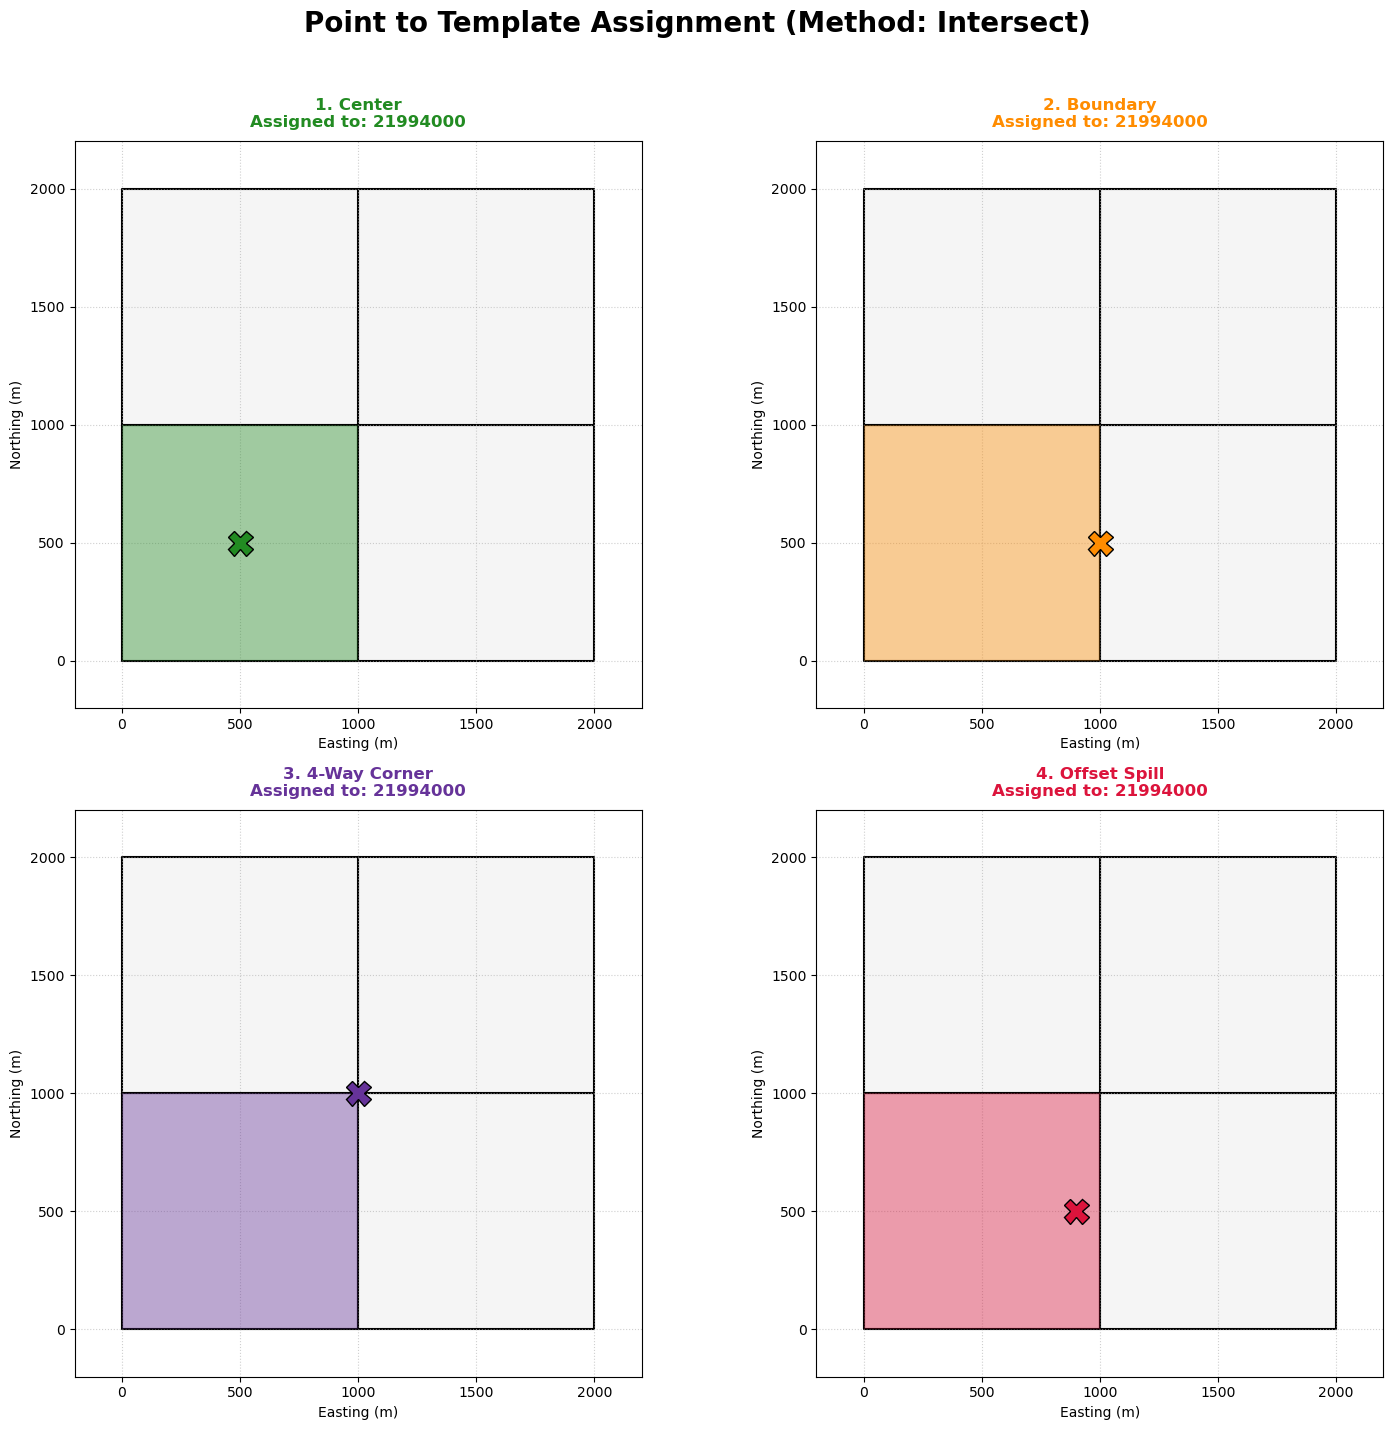

In [8]:
cells = [
    Polygon([(0, 0), (1000, 0), (1000, 1000), (0, 1000)]),             
    Polygon([(1000, 0), (2000, 0), (2000, 1000), (1000, 1000)]),       
    Polygon([(1000, 1000), (2000, 1000), (2000, 2000), (1000, 2000)]), 
    Polygon([(0, 1000), (1000, 1000), (1000, 2000), (0, 2000)])        
]
labels = ["21994000", "Cell_1000_0", "Cell_1000_1000", "Cell_0_1000"]
grid_gdf = gpd.GeoDataFrame({'grid_idx': labels}, geometry=cells, crs="EPSG:3035")

# =====================================================================
# 3. VISUALIZATION (With Fixed Type-Matching Filter)
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()
plt.suptitle("Point to Template Assignment (Method: Intersect)", fontsize=20, fontweight='bold', y=0.95)

colors = ['forestgreen', 'darkorange', 'rebeccapurple', 'crimson']

for idx, row in mapped_points.iterrows():
    ax = axes[idx]
    color = colors[idx]
    
    # Set viewport
    ax.set_aspect('equal')
    ax.set_xlim(-200, 2200)
    ax.set_ylim(-200, 2200)
    
    # 1. Draw the base grid (empty cells)
    grid_gdf.plot(ax=ax, facecolor='whitesmoke', edgecolor='black', linewidth=1.5, zorder=1)
    
    # 2. Highlight the assigned cell with a colored opaque background
    # FIXED: Cast both sides to strings to ensure matching regardless of Int/Object dtypes
    assigned_cell = grid_gdf[grid_gdf['grid_idx'].astype(str) == str(row['grid_idx'])]
    
    if not assigned_cell.empty:
        assigned_cell.plot(ax=ax, facecolor=color, alpha=0.4, edgecolor='black', linewidth=1.5, zorder=2)
    
    # 3. Plot the point
    ax.plot(
        row.geometry.x, row.geometry.y, 
        marker='X', color=color, markersize=18, markeredgecolor='black', zorder=5
    )
    
    # Formatting
    ax.set_title(f"{row['obs_id']}\nAssigned to: {row['grid_idx']}", fontweight='bold', color=color, pad=10)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
    
    ax.set_xticks(np.arange(0, 2001, 500))
    ax.set_yticks(np.arange(0, 2001, 500))
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Point cloud to template

For observations burdened with coordinate uncertainty, the `map_point_cloud_to_template` method computes probabilistic point clouds distribution intersects, mapping accurately fractional mappings directly on the configured spatial topology blueprint templates. This method provides two distinct calculation modes:
*   **Fractional Weighting (`mode="fractional"`):** Distributes the cloud across multiple grid cells, generating a fraction weights array parameter that tracks the distributed weighting allocation. This preserves the spatial mass of an observation across the boundary.
*   **Cell Classification (`mode="classify"`):** Evaluates the densest cluster of the point cloud and assigns the entire observation to a single optimal grid index without splitting its volume into fractions.

#### Point cloud cell classification

##### KDtree Gaussian cloud

In [9]:
# Point Cloud to Template (Classification via KDTree)
mapped_clouds_class = engine.map_point_cloud_to_template(
    source_gdf=clouds_gauss_gdf,
    target_grid_name="EEA_1km",
    geom_column="point_cloud",
    output_col="grid_idx",
    mode="classify",
    classify_method="kdtree"
)
mapped_clouds_class

,obs_id,uncertainty,geometry,passes,weight_per_point,grid_idx,src_grid_idx
0,1. Center,100.0,POINT (500 500),200,0.005,21994000,21994000
1,2. Boundary,300.0,POINT (1000 500),200,0.005,21994001,21994000
2,3. 4-Way Corner,700.0,POINT (1000 1000),200,0.005,21990000,21990000
3,4. Offset Spill,1000.0,POINT (900 500),200,0.005,21994000,21994000


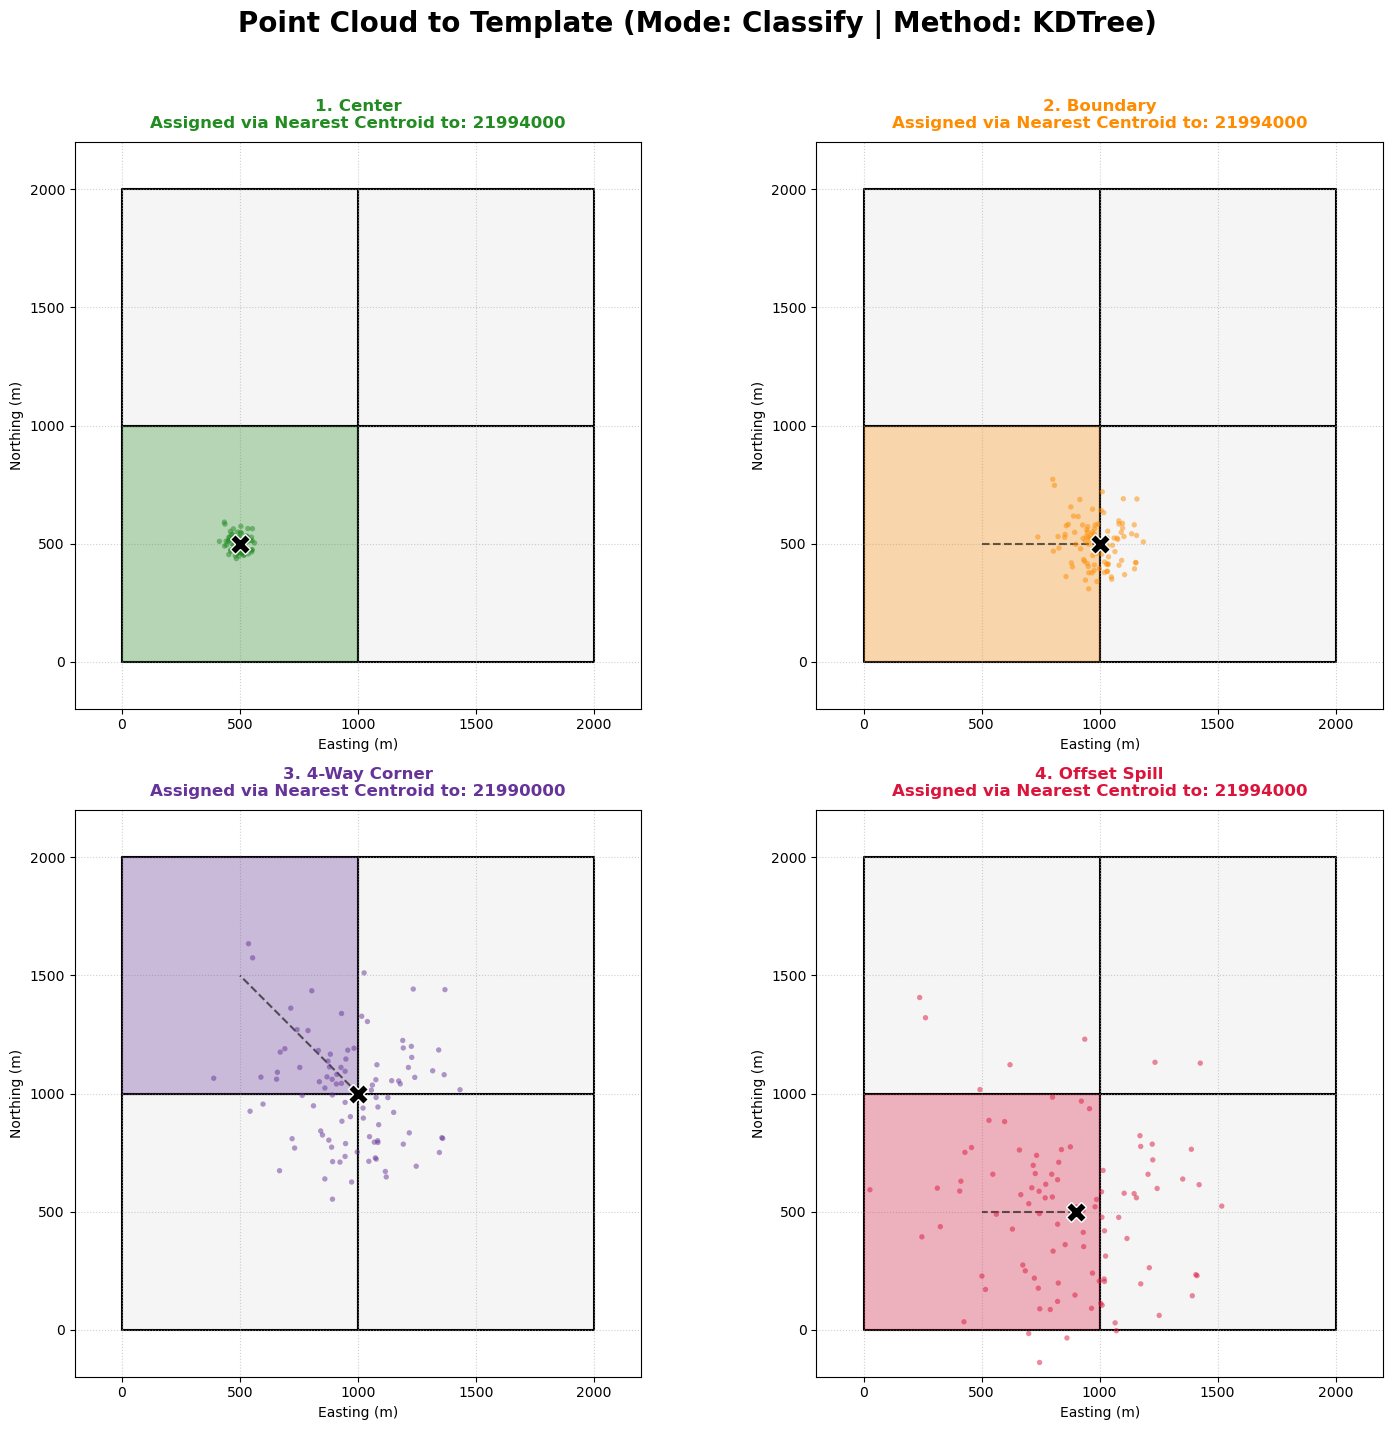

In [15]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# =====================================================================
# 1. 2x2 MASTER GRID WITH DETERMINISTIC EEA GRID INDICES
# =====================================================================
cells = [
    Polygon([(0, 0), (1000, 0), (1000, 1000), (0, 1000)]),             # Bottom-Left (21994000)
    Polygon([(1000, 0), (2000, 0), (2000, 1000), (1000, 1000)]),       # Bottom-Right (21994001)
    Polygon([(1000, 1000), (2000, 1000), (2000, 2000), (1000, 2000)]), # Top-Right (21990001)
    Polygon([(0, 1000), (1000, 1000), (1000, 2000), (0, 2000)])        # Top-Left (21990000)
]
labels = ["21994000", "21994001", "21990001", "21990000"]
grid_gdf = gpd.GeoDataFrame({'grid_idx': labels}, geometry=cells, crs="EPSG:3035")

# =====================================================================
# 2. VISUALIZATION CODE
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()
plt.suptitle("Point Cloud to Template (Mode: Classify | Method: KDTree)", fontsize=20, fontweight='bold', y=0.95)

colors = ['forestgreen', 'darkorange', 'rebeccapurple', 'crimson']

for idx, row in mapped_clouds_class.iterrows():
    ax = axes[idx]
    color = colors[idx]
    
    # Set viewport
    ax.set_aspect('equal')
    ax.set_xlim(-200, 2200)
    ax.set_ylim(-200, 2200)
    
    # 1. Draw base grid
    grid_gdf.plot(ax=ax, facecolor='whitesmoke', edgecolor='black', linewidth=1.5, zorder=1)
    
    # 2. Highlight assigned cell
    assigned_cell = grid_gdf[grid_gdf['grid_idx'].astype(str) == str(row['grid_idx'])]
    if not assigned_cell.empty:
        assigned_cell.plot(ax=ax, facecolor=color, alpha=0.3, edgecolor='black', linewidth=1.5, zorder=2)
    
    # 3. Plot actual point cloud geometries from clouds_gauss_gdf
    if 'point_cloud' in row and row['point_cloud'] is not None:
        mp = row['point_cloud']
        cloud_x = [pt.x for pt in mp.geoms]
        cloud_y = [pt.y for pt in mp.geoms]
    else:
        # Fallback random generation
        np.random.seed(42)
        cloud_x = np.random.normal(loc=row.geometry.x, scale=row['uncertainty']/3, size=100)
        cloud_y = np.random.normal(loc=row.geometry.y, scale=row['uncertainty']/3, size=100)
        
    ax.scatter(cloud_x, cloud_y, color=color, alpha=0.5, s=15, edgecolor='none', zorder=4)
    
    # 4. Plot original centroid
    ax.plot(
        row.geometry.x, row.geometry.y, 
        marker='X', color='black', markersize=14, markeredgecolor='white', zorder=5
    )
    
    # 5. Draw line to assigned cell centroid
    if not assigned_cell.empty:
        target_centroid = assigned_cell.geometry.centroid.iloc[0]
        ax.plot([row.geometry.x, target_centroid.x], [row.geometry.y, target_centroid.y], 
                color='black', linestyle='--', alpha=0.6, zorder=3)
    
    # Formatting
    ax.set_title(f"{row['obs_id']}\nAssigned via Nearest Centroid to: {row['grid_idx']}", 
                 fontweight='bold', color=color, pad=10)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
    
    ax.set_xticks(np.arange(0, 2001, 500))
    ax.set_yticks(np.arange(0, 2001, 500))
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

##### Intersect Gaussian cloud

In [32]:
# Point Cloud to Template (Classification via intersect)
mapped_cloud_gauss_class = engine.map_point_cloud_to_template(
    source_gdf=clouds_gauss_gdf,
    target_grid_name="EEA_1km",
    geom_column="point_cloud",
    output_col="grid_idx",
    mode="classify",
    classify_method="intersect"
)
mapped_cloud_gauss_class

,obs_id,uncertainty,geometry,passes,weight_per_point,grid_idx,src_grid_idx
0,1. Center,100.0,POINT (500 500),200,0.005,21994000,21994000
1,2. Boundary,300.0,POINT (1000 500),200,0.005,21994001,21994000
2,3. 4-Way Corner,700.0,POINT (1000 1000),200,0.005,21990000,21990000
3,4. Offset Spill,1000.0,POINT (900 500),200,0.005,21994000,21994000


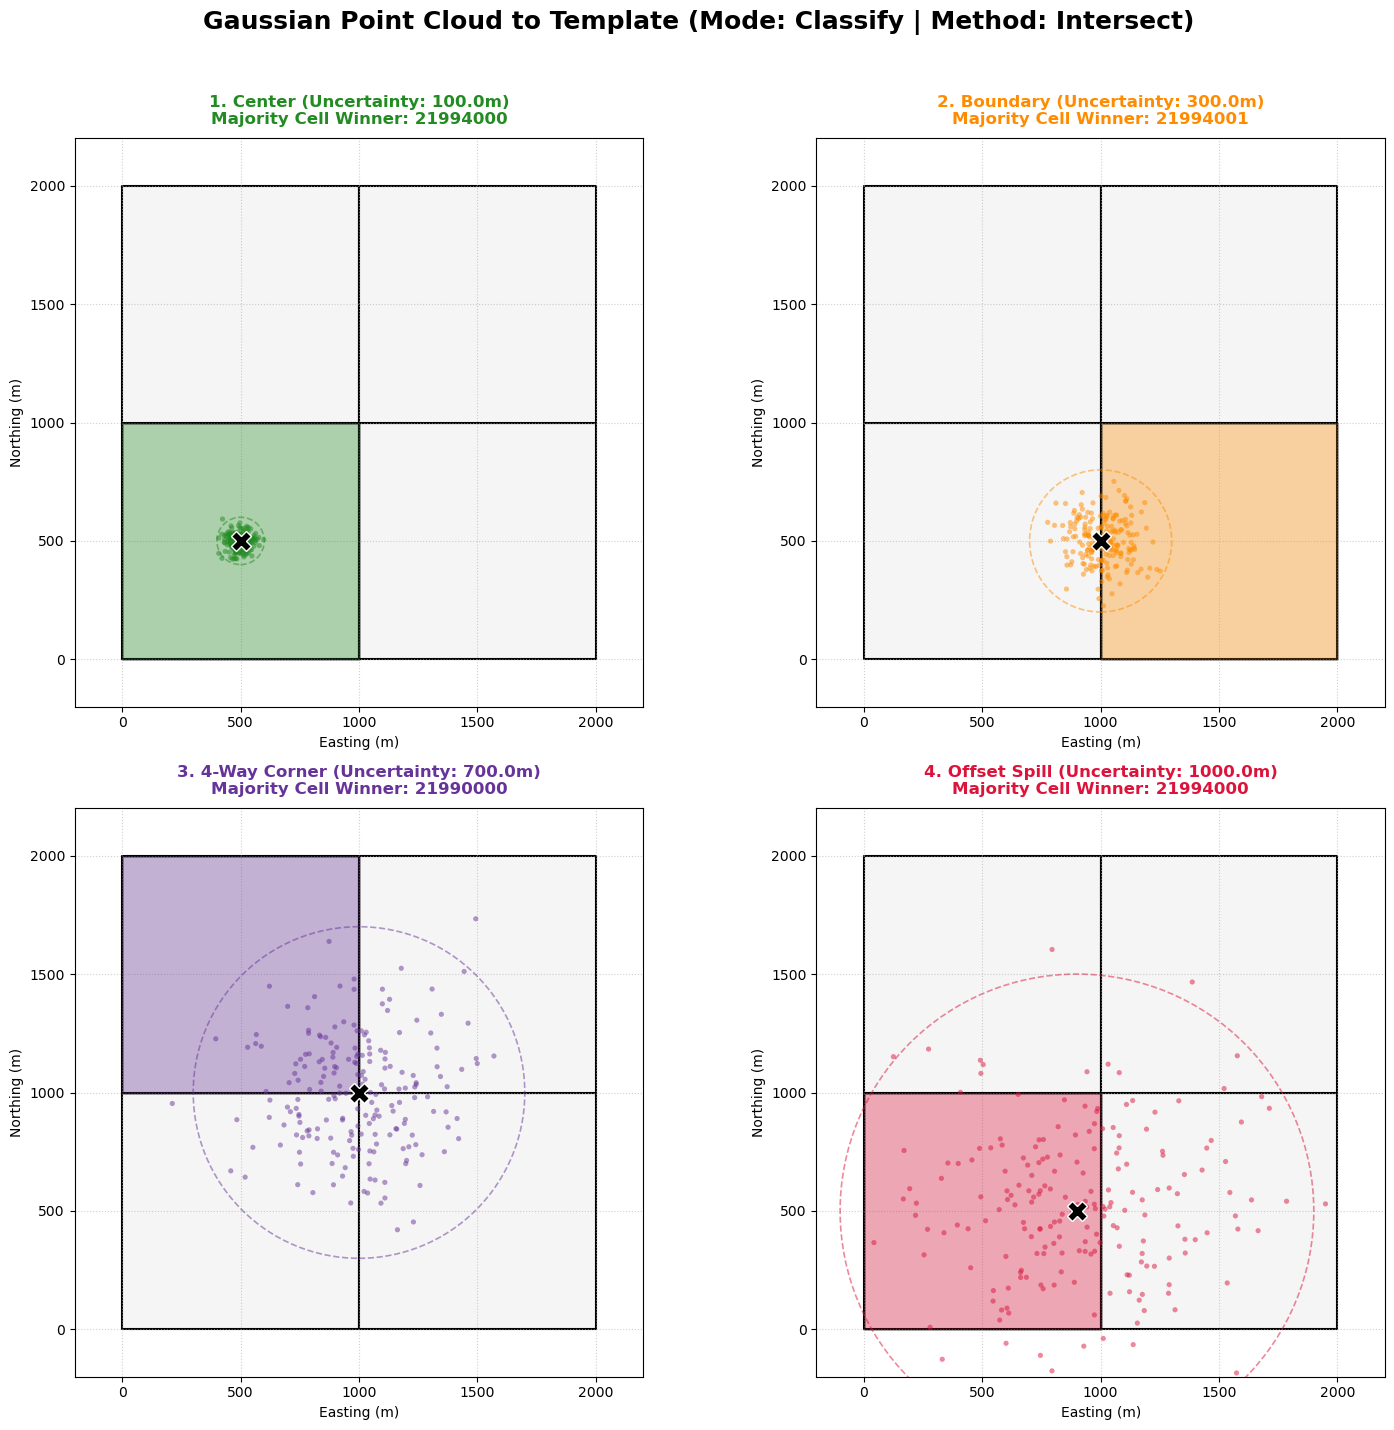

In [33]:
# =====================================================================
# 1. DEFINE TEMPLATE GRID (EEA 1km 2x2 Local Mesh)
# =====================================================================
cells = [
    Polygon([(0, 0), (1000, 0), (1000, 1000), (0, 1000)]),             # Bottom-Left (21994000)
    Polygon([(1000, 0), (2000, 0), (2000, 1000), (1000, 1000)]),       # Bottom-Right (21994001)
    Polygon([(0, 1000), (1000, 1000), (1000, 2000), (0, 2000)]),        # Top-Left (21990000)
    Polygon([(1000, 1000), (2000, 1000), (2000, 2000), (1000, 2000)]), # Top-Right (21990001)
]
labels = ["21994000", "21994001", "21990000", "21990001"]
grid_gdf = gpd.GeoDataFrame({'grid_idx': labels}, geometry=cells, crs="EPSG:3035")

# =====================================================================
# 2. VISUALIZATION CODE (Mode: Classify | Method: Intersect | Gaussian)
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()
plt.suptitle("Gaussian Point Cloud to Template (Mode: Classify | Method: Intersect)", fontsize=18, fontweight='bold', y=0.95)

colors = ['forestgreen', 'darkorange', 'rebeccapurple', 'crimson']

for idx, row in mapped_cloud_gauss_class.iterrows():
    ax = axes[idx]
    color = colors[idx]
    
    # Set viewport
    ax.set_aspect('equal')
    ax.set_xlim(-200, 2200)
    ax.set_ylim(-200, 2200)
    
    # 1. Draw base template grid
    grid_gdf.plot(ax=ax, facecolor='whitesmoke', edgecolor='black', linewidth=1.5, zorder=1)
    
    # 2. Highlight winning majority cell selected by Intersect
    assigned_cell = grid_gdf[grid_gdf['grid_idx'].astype(str) == str(row['grid_idx'])]
    if not assigned_cell.empty:
        assigned_cell.plot(ax=ax, facecolor=color, alpha=0.35, edgecolor='black', linewidth=2.0, zorder=2)
    
    # 3. Extract MultiPoint Gaussian cloud from clouds_gauss_gdf if in memory
    if 'clouds_gauss_gdf' in globals() and 'point_cloud' in clouds_gauss_gdf.columns:
        orig_match = clouds_gauss_gdf[clouds_gauss_gdf['obs_id'] == row['obs_id']]
        if not orig_match.empty and orig_match.iloc[0]['point_cloud'] is not None:
            mp = orig_match.iloc[0]['point_cloud']
            cloud_x = [pt.x for pt in mp.geoms]
            cloud_y = [pt.y for pt in mp.geoms]
        else:
            np.random.seed(42 + idx)
            scale = row['uncertainty'] / 3.0  # 3-sigma radius
            cloud_x = np.random.normal(loc=row.geometry.x, scale=scale, size=150)
            cloud_y = np.random.normal(loc=row.geometry.y, scale=scale, size=150)
    else:
        np.random.seed(42 + idx)
        scale = row['uncertainty'] / 3.0
        cloud_x = np.random.normal(loc=row.geometry.x, scale=scale, size=150)
        cloud_y = np.random.normal(loc=row.geometry.y, scale=scale, size=150)

    # Plot Gaussian cloud scatter and 3-sigma uncertainty boundary
    ax.scatter(cloud_x, cloud_y, color=color, alpha=0.5, s=14, edgecolor='none', zorder=4)
    circle = plt.Circle((row.geometry.x, row.geometry.y), row['uncertainty'], color=color, fill=False, linestyle='--', alpha=0.5, linewidth=1.2, zorder=3)
    ax.add_patch(circle)
    
    # 4. Plot origin centroid marker ('X')
    ax.plot(
        row.geometry.x, row.geometry.y, 
        marker='X', color='black', markersize=14, markeredgecolor='white', zorder=5
    )
    
    # Formatting
    ax.set_title(f"{row['obs_id']} (Uncertainty: {row['uncertainty']}m)\nMajority Cell Winner: {row['grid_idx']}", 
                 fontweight='bold', color=color, pad=10)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
    
    ax.set_xticks(np.arange(0, 2001, 500))
    ax.set_yticks(np.arange(0, 2001, 500))
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

##### KDtree Uniform cloud

In [34]:
# Point Cloud to Template (Classification via intersect)
mapped_clouds_uni_class = engine.map_point_cloud_to_template(
    source_gdf=clouds_uni_gdf,
    target_grid_name="EEA_1km",
    geom_column="point_cloud",
    output_col="grid_idx",
    mode="classify",
    classify_method="kdtree"
)
mapped_clouds_uni_class

,obs_id,uncertainty,geometry,passes,weight_per_point,grid_idx,src_grid_idx
0,1. Center,100.0,POINT (500 500),200,0.005,21994000,21994000
1,2. Boundary,300.0,POINT (1000 500),200,0.005,21994000,21994000
2,3. 4-Way Corner,700.0,POINT (1000 1000),200,0.005,21990000,21990000
3,4. Offset Spill,1000.0,POINT (900 500),200,0.005,21994000,21994000


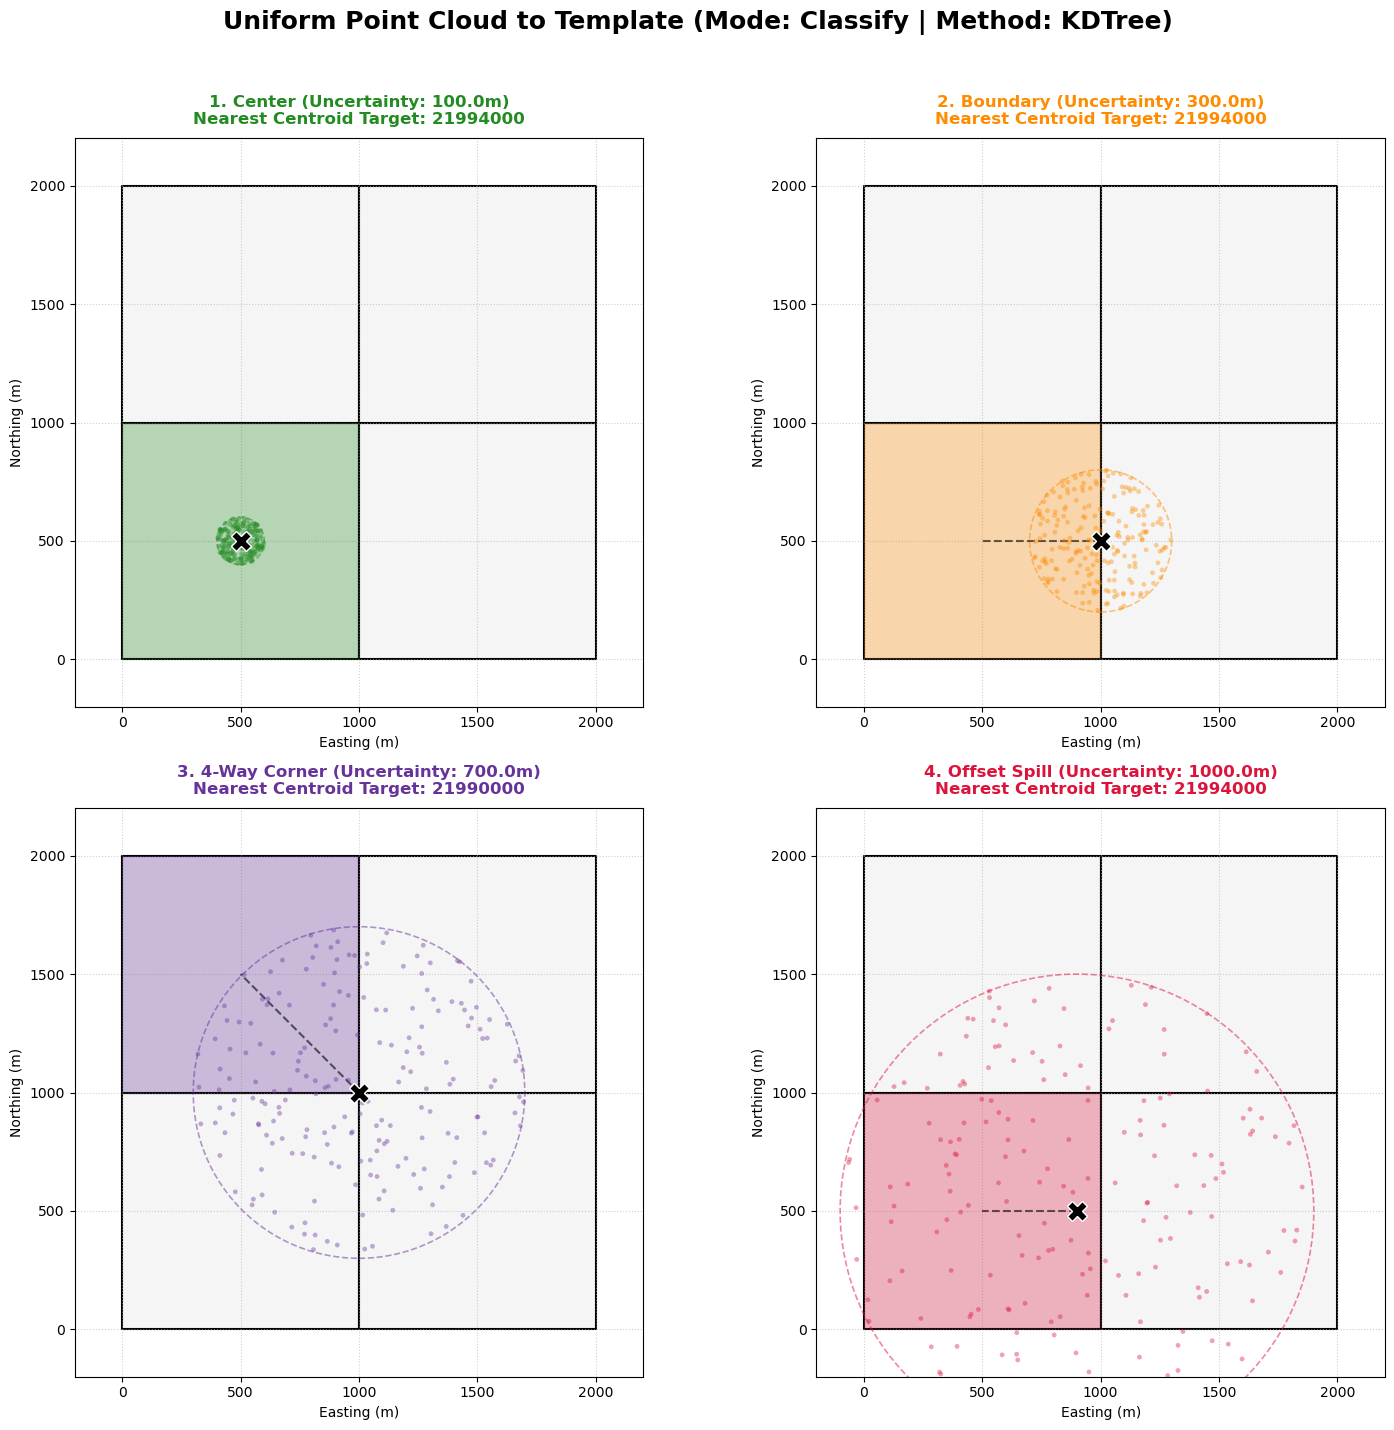

In [35]:
# =====================================================================
# 1. DEFINE TEMPLATE GRID (EEA 1km 2x2 Local Mesh)
# =====================================================================
cells = [
    Polygon([(0, 0), (1000, 0), (1000, 1000), (0, 1000)]),             # Bottom-Left (21994000)
    Polygon([(1000, 0), (2000, 0), (2000, 1000), (1000, 1000)]),       # Bottom-Right (21994001)
    Polygon([(0, 1000), (1000, 1000), (1000, 2000), (0, 2000)]),        # Top-Left (21990000)
    Polygon([(1000, 1000), (2000, 1000), (2000, 2000), (1000, 2000)]), # Top-Right (21990001)
]
labels = ["21994000", "21994001", "21990000", "21990001"]
grid_gdf = gpd.GeoDataFrame({'grid_idx': labels}, geometry=cells, crs="EPSG:3035")

# =====================================================================
# 2. VISUALIZATION CODE (Mode: Classify | Method: KDTree | Uniform)
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()
plt.suptitle("Uniform Point Cloud to Template (Mode: Classify | Method: KDTree)", fontsize=18, fontweight='bold', y=0.95)

colors = ['forestgreen', 'darkorange', 'rebeccapurple', 'crimson']

for idx, row in mapped_clouds_uni_class.iterrows():
    ax = axes[idx]
    color = colors[idx]
    
    # Set viewport
    ax.set_aspect('equal')
    ax.set_xlim(-200, 2200)
    ax.set_ylim(-200, 2200)
    
    # 1. Draw base template grid
    grid_gdf.plot(ax=ax, facecolor='whitesmoke', edgecolor='black', linewidth=1.5, zorder=1)
    
    # 2. Highlight assigned cell selected by KDTree
    assigned_cell = grid_gdf[grid_gdf['grid_idx'].astype(str) == str(row['grid_idx'])]
    if not assigned_cell.empty:
        assigned_cell.plot(ax=ax, facecolor=color, alpha=0.3, edgecolor='black', linewidth=1.5, zorder=2)
    
    # 3. Extract MultiPoint cloud from clouds_uni_gdf (or generate fallback disk scatter)
    if 'clouds_uni_gdf' in globals() and 'point_cloud' in clouds_uni_gdf.columns:
        orig_match = clouds_uni_gdf[clouds_uni_gdf['obs_id'] == row['obs_id']]
        if not orig_match.empty and orig_match.iloc[0]['point_cloud'] is not None:
            mp = orig_match.iloc[0]['point_cloud']
            cloud_x = [pt.x for pt in mp.geoms]
            cloud_y = [pt.y for pt in mp.geoms]
        else:
            np.random.seed(42 + idx)
            r = row['uncertainty'] * np.sqrt(np.random.uniform(0, 1, 150))
            theta = np.random.uniform(0, 2 * np.pi, 150)
            cloud_x = row.geometry.x + r * np.cos(theta)
            cloud_y = row.geometry.y + r * np.sin(theta)
    else:
        np.random.seed(42 + idx)
        r = row['uncertainty'] * np.sqrt(np.random.uniform(0, 1, 150))
        theta = np.random.uniform(0, 2 * np.pi, 150)
        cloud_x = row.geometry.x + r * np.cos(theta)
        cloud_y = row.geometry.y + r * np.sin(theta)

    # Plot point cloud scatter and uncertainty radius
    ax.scatter(cloud_x, cloud_y, color=color, alpha=0.4, s=12, edgecolor='none', zorder=4)
    circle = plt.Circle((row.geometry.x, row.geometry.y), row['uncertainty'], color=color, fill=False, linestyle='--', alpha=0.5, linewidth=1.2, zorder=3)
    ax.add_patch(circle)
    
    # 4. Plot origin centroid marker ('X')
    ax.plot(
        row.geometry.x, row.geometry.y, 
        marker='X', color='black', markersize=14, markeredgecolor='white', zorder=5
    )
    
    # 5. Draw connector line to the assigned cell centroid
    if not assigned_cell.empty:
        target_centroid = assigned_cell.geometry.centroid.iloc[0]
        ax.plot([row.geometry.x, target_centroid.x], [row.geometry.y, target_centroid.y], 
                color='black', linestyle='--', alpha=0.6, zorder=3)
    
    # Formatting
    ax.set_title(f"{row['obs_id']} (Uncertainty: {row['uncertainty']}m)\nNearest Centroid Target: {row['grid_idx']}", 
                 fontweight='bold', color=color, pad=10)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
    
    ax.set_xticks(np.arange(0, 2001, 500))
    ax.set_yticks(np.arange(0, 2001, 500))
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

##### Intersect Uniform Cloud

In [36]:
# Point Cloud to Template (Classification via intersect)
mapped_clouds_uni_class = engine.map_point_cloud_to_template(
    source_gdf=clouds_uni_gdf,
    target_grid_name="EEA_1km",
    geom_column="point_cloud",
    output_col="grid_idx",
    mode="classify",
    classify_method="intersect"
)
mapped_clouds_uni_class

,obs_id,uncertainty,geometry,passes,weight_per_point,grid_idx,src_grid_idx
0,1. Center,100.0,POINT (500 500),200,0.005,21994000,21994000
1,2. Boundary,300.0,POINT (1000 500),200,0.005,21994000,21994000
2,3. 4-Way Corner,700.0,POINT (1000 1000),200,0.005,21990000,21990000
3,4. Offset Spill,1000.0,POINT (900 500),200,0.005,21994000,21994000


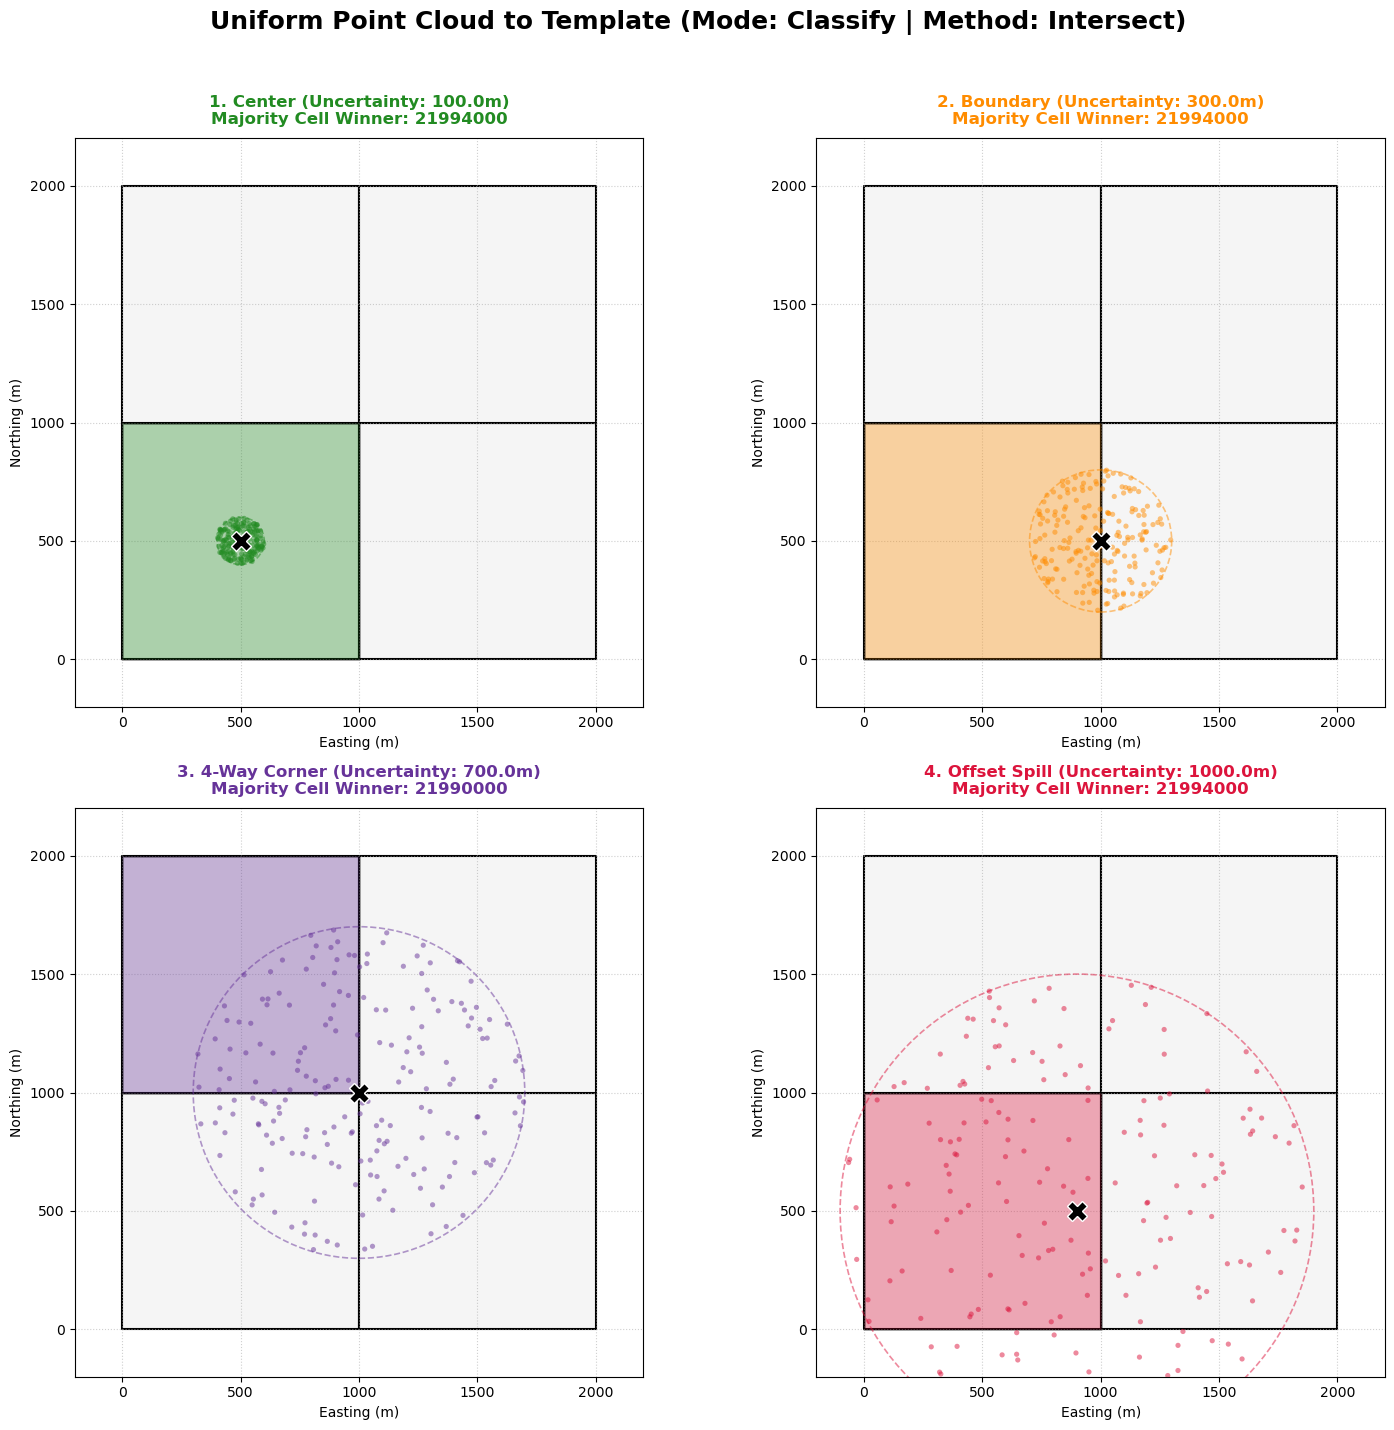

In [37]:
# =====================================================================
# 1. DEFINE TEMPLATE GRID (EEA 1km 2x2 Local Mesh)
# =====================================================================
cells = [
    Polygon([(0, 0), (1000, 0), (1000, 1000), (0, 1000)]),             # Bottom-Left (21994000)
    Polygon([(1000, 0), (2000, 0), (2000, 1000), (1000, 1000)]),       # Bottom-Right (21994001)
    Polygon([(0, 1000), (1000, 1000), (1000, 2000), (0, 2000)]),        # Top-Left (21990000)
    Polygon([(1000, 1000), (2000, 1000), (2000, 2000), (1000, 2000)]), # Top-Right (21990001)
]
labels = ["21994000", "21994001", "21990000", "21990001"]
grid_gdf = gpd.GeoDataFrame({'grid_idx': labels}, geometry=cells, crs="EPSG:3035")

# =====================================================================
# 2. VISUALIZATION CODE (Mode: Classify | Method: Intersect | Uniform)
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()
plt.suptitle("Uniform Point Cloud to Template (Mode: Classify | Method: Intersect)", fontsize=18, fontweight='bold', y=0.95)

colors = ['forestgreen', 'darkorange', 'rebeccapurple', 'crimson']

for idx, row in mapped_clouds_uni_class.iterrows():
    ax = axes[idx]
    color = colors[idx]
    
    # Set viewport
    ax.set_aspect('equal')
    ax.set_xlim(-200, 2200)
    ax.set_ylim(-200, 2200)
    
    # 1. Draw base template grid
    grid_gdf.plot(ax=ax, facecolor='whitesmoke', edgecolor='black', linewidth=1.5, zorder=1)
    
    # 2. Highlight winning majority cell selected by Intersect
    assigned_cell = grid_gdf[grid_gdf['grid_idx'].astype(str) == str(row['grid_idx'])]
    if not assigned_cell.empty:
        assigned_cell.plot(ax=ax, facecolor=color, alpha=0.35, edgecolor='black', linewidth=2.0, zorder=2)
    
    # 3. Extract MultiPoint uniform cloud from clouds_uni_gdf if in memory
    if 'clouds_uni_gdf' in globals() and 'point_cloud' in clouds_uni_gdf.columns:
        orig_match = clouds_uni_gdf[clouds_uni_gdf['obs_id'] == row['obs_id']]
        if not orig_match.empty and orig_match.iloc[0]['point_cloud'] is not None:
            mp = orig_match.iloc[0]['point_cloud']
            cloud_x = [pt.x for pt in mp.geoms]
            cloud_y = [pt.y for pt in mp.geoms]
        else:
            np.random.seed(42 + idx)
            r = row['uncertainty'] * np.sqrt(np.random.uniform(0, 1, 150))
            theta = np.random.uniform(0, 2 * np.pi, 150)
            cloud_x = row.geometry.x + r * np.cos(theta)
            cloud_y = row.geometry.y + r * np.sin(theta)
    else:
        np.random.seed(42 + idx)
        r = row['uncertainty'] * np.sqrt(np.random.uniform(0, 1, 150))
        theta = np.random.uniform(0, 2 * np.pi, 150)
        cloud_x = row.geometry.x + r * np.cos(theta)
        cloud_y = row.geometry.y + r * np.sin(theta)

    # Plot Uniform cloud scatter and uncertainty disc boundary
    ax.scatter(cloud_x, cloud_y, color=color, alpha=0.5, s=14, edgecolor='none', zorder=4)
    circle = plt.Circle((row.geometry.x, row.geometry.y), row['uncertainty'], color=color, fill=False, linestyle='--', alpha=0.5, linewidth=1.2, zorder=3)
    ax.add_patch(circle)
    
    # 4. Plot origin centroid marker ('X')
    ax.plot(
        row.geometry.x, row.geometry.y, 
        marker='X', color='black', markersize=14, markeredgecolor='white', zorder=5
    )
    
    # Formatting
    ax.set_title(f"{row['obs_id']} (Uncertainty: {row['uncertainty']}m)\nMajority Cell Winner: {row['grid_idx']}", 
                 fontweight='bold', color=color, pad=10)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
    
    ax.set_xticks(np.arange(0, 2001, 500))
    ax.set_yticks(np.arange(0, 2001, 500))
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

#### Fractional weight calculation

##### Gaussian

In [27]:
# Point Cloud to Template (Classification via intersect)
gauss_frac_gdf = engine.map_point_cloud_to_template(
    source_gdf=clouds_gauss_gdf,
    target_grid_name="EEA_1km",
    geom_column="point_cloud",
    output_col="grid_idx",
    mode="fractional",
    classify_method="intersect"
)
gauss_frac_gdf

,grid_idx,src_grid_idx,fraction,src_uid,obs_id,uncertainty,passes,weight_per_point
0,21994000,21994000,1.000,0,1. Center,100.0,200,0.005
1,21994000,21994000,0.440,1,2. Boundary,300.0,200,0.005
2,21994001,21994000,0.560,1,2. Boundary,300.0,200,0.005
3,21990000,21990000,0.265,2,3. 4-Way Corner,700.0,200,0.005
4,21990001,21990000,0.240,2,3. 4-Way Corner,700.0,200,0.005
5,21994000,21990000,0.260,2,3. 4-Way Corner,700.0,200,0.005
6,21994001,21990000,0.235,2,3. 4-Way Corner,700.0,200,0.005
7,21990000,21994000,0.040,3,4. Offset Spill,1000.0,200,0.005
8,21990001,21994000,0.025,3,4. Offset Spill,1000.0,200,0.005
9,21994000,21994000,0.545,3,4. Offset Spill,1000.0,200,0.005


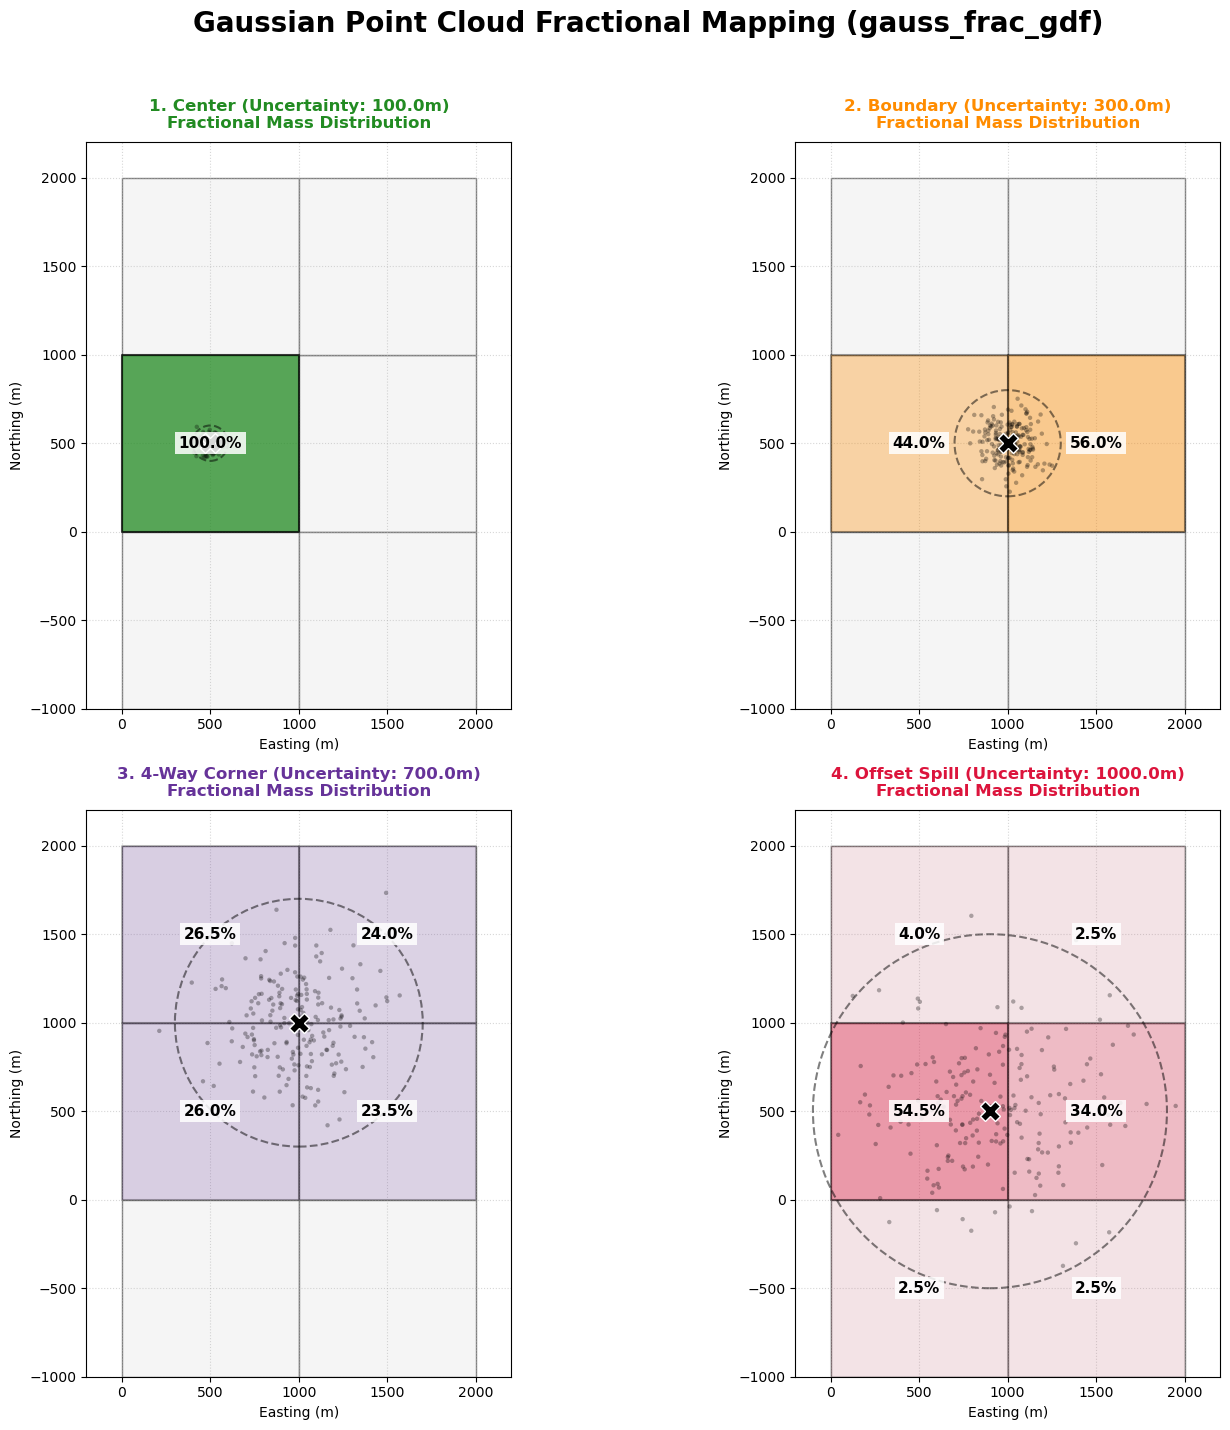

In [28]:
grid_definitions = {
    21994000: Polygon([(0, 0), (1000, 0), (1000, 1000), (0, 1000)]),          # Main Bottom-Left
    21994001: Polygon([(1000, 0), (2000, 0), (2000, 1000), (1000, 1000)]),    # Main Bottom-Right
    21990000: Polygon([(0, 1000), (1000, 1000), (1000, 2000), (0, 2000)]),     # Main Top-Left
    21990001: Polygon([(1000, 1000), (2000, 1000), (2000, 2000), (1000, 2000)]),# Main Top-Right
    21998000: Polygon([(0, -1000), (1000, -1000), (1000, 0), (0, 0)]),        # South Bottom-Left
    21998001: Polygon([(1000, -1000), (2000, -1000), (2000, 0), (1000, 0)]),  # South Bottom-Right
}

grid_gdf = gpd.GeoDataFrame(
    {'grid_idx': list(grid_definitions.keys())},
    geometry=list(grid_definitions.values()),
    crs="EPSG:3035"
)

# =====================================================================
# 2. VISUALIZATION DIRECTLY FROM gauss_frac_gdf
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()
plt.suptitle("Gaussian Point Cloud Fractional Mapping (gauss_frac_gdf)", fontsize=20, fontweight='bold', y=0.95)

colors = ['forestgreen', 'darkorange', 'rebeccapurple', 'crimson']
unique_obs = gauss_frac_gdf['obs_id'].unique()

for idx, obs_name in enumerate(unique_obs):
    ax = axes[idx]
    color = colors[idx]
    
    # Filter fractional mapping results for the current observation
    obs_data = gauss_frac_gdf[gauss_frac_gdf['obs_id'] == obs_name]
    
    # Set viewport to comfortably show the main grid and southern spillover
    ax.set_aspect('equal')
    ax.set_xlim(-200, 2200)
    ax.set_ylim(-300, 2200)
    
    # 1. Base Grid Outline
    grid_gdf.plot(ax=ax, facecolor='whitesmoke', edgecolor='gray', linewidth=1.0, zorder=1)
    
    # 2. Highlight cells with opacity (alpha) driven by the fraction column
    for _, frac_row in obs_data.iterrows():
        cell = grid_gdf[grid_gdf['grid_idx'].astype(str) == str(frac_row['grid_idx'])]
        if not cell.empty:
            f_val = frac_row['fraction']
            # Scale alpha proportional to fraction (minimum threshold 0.08 for visibility)
            alpha_val = max(f_val * 0.75, 0.08)
            
            # Shade assigned cell
            cell.plot(ax=ax, facecolor=color, alpha=alpha_val, edgecolor='black', linewidth=1.5, zorder=2)
            
            # Label percentage inside cell centroid
            centroid = cell.geometry.centroid.iloc[0]
            ax.text(
                centroid.x, centroid.y, f"{f_val * 100:.1f}%", 
                ha='center', va='center', fontweight='bold', fontsize=11,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=2.5), zorder=6
            )
            
    # 3. Optional Overlay: Draw actual point cloud scatter if clouds_gauss_gdf exists
    if 'clouds_gauss_gdf' in globals():
        orig_match = clouds_gauss_gdf[clouds_gauss_gdf['obs_id'] == obs_name]
        if not orig_match.empty:
            row_orig = orig_match.iloc[0]
            
            # Scatter MultiPoint cloud
            if 'point_cloud' in row_orig and row_orig['point_cloud'] is not None:
                mp = row_orig['point_cloud']
                cloud_x = [pt.x for pt in mp.geoms]
                cloud_y = [pt.y for pt in mp.geoms]
                ax.scatter(cloud_x, cloud_y, color='black', alpha=0.3, s=10, edgecolor='none', zorder=4)
            
            # Origin Point & Uncertainty Circle
            ox, oy = row_orig.geometry.x, row_orig.geometry.y
            uncert = row_orig['uncertainty']
            ax.plot(ox, oy, marker='X', color='black', markersize=14, markeredgecolor='white', zorder=5)
            circle = plt.Circle((ox, oy), uncert, color='black', fill=False, linestyle='--', alpha=0.5, linewidth=1.5, zorder=3)
            ax.add_patch(circle)

    # Formatting
    uncert_val = obs_data['uncertainty'].iloc[0]
    ax.set_title(f"{obs_name} (Uncertainty: {uncert_val}m)\nFractional Mass Distribution", fontweight='bold', color=color, pad=10)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax.set_xticks(np.arange(0, 2001, 500))
    ax.set_yticks(np.arange(-1000, 2001, 500))
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

##### Uniform

In [26]:
# Point Cloud to Template (Classification via intersect)
frac_uni_gdf = engine.map_point_cloud_to_template(
    source_gdf=clouds_uni_gdf,
    target_grid_name="EEA_1km",
    geom_column="point_cloud",
    output_col="grid_idx",
    mode="fractional",
    classify_method="intersect"
)
frac_uni_gdf

,grid_idx,src_grid_idx,fraction,src_uid,obs_id,uncertainty,passes,weight_per_point
0,21994000,21994000,1.000,0,1. Center,100.0,200,0.005
1,21994000,21994000,0.520,1,2. Boundary,300.0,200,0.005
2,21994001,21994000,0.480,1,2. Boundary,300.0,200,0.005
3,21990000,21990000,0.270,2,3. 4-Way Corner,700.0,200,0.005
4,21990001,21990000,0.250,2,3. 4-Way Corner,700.0,200,0.005
5,21994000,21990000,0.240,2,3. 4-Way Corner,700.0,200,0.005
6,21994001,21990000,0.240,2,3. 4-Way Corner,700.0,200,0.005
7,21990000,21994000,0.145,3,4. Offset Spill,1000.0,200,0.005
8,21990001,21994000,0.055,3,4. Offset Spill,1000.0,200,0.005
9,21993999,21994000,0.020,3,4. Offset Spill,1000.0,200,0.005


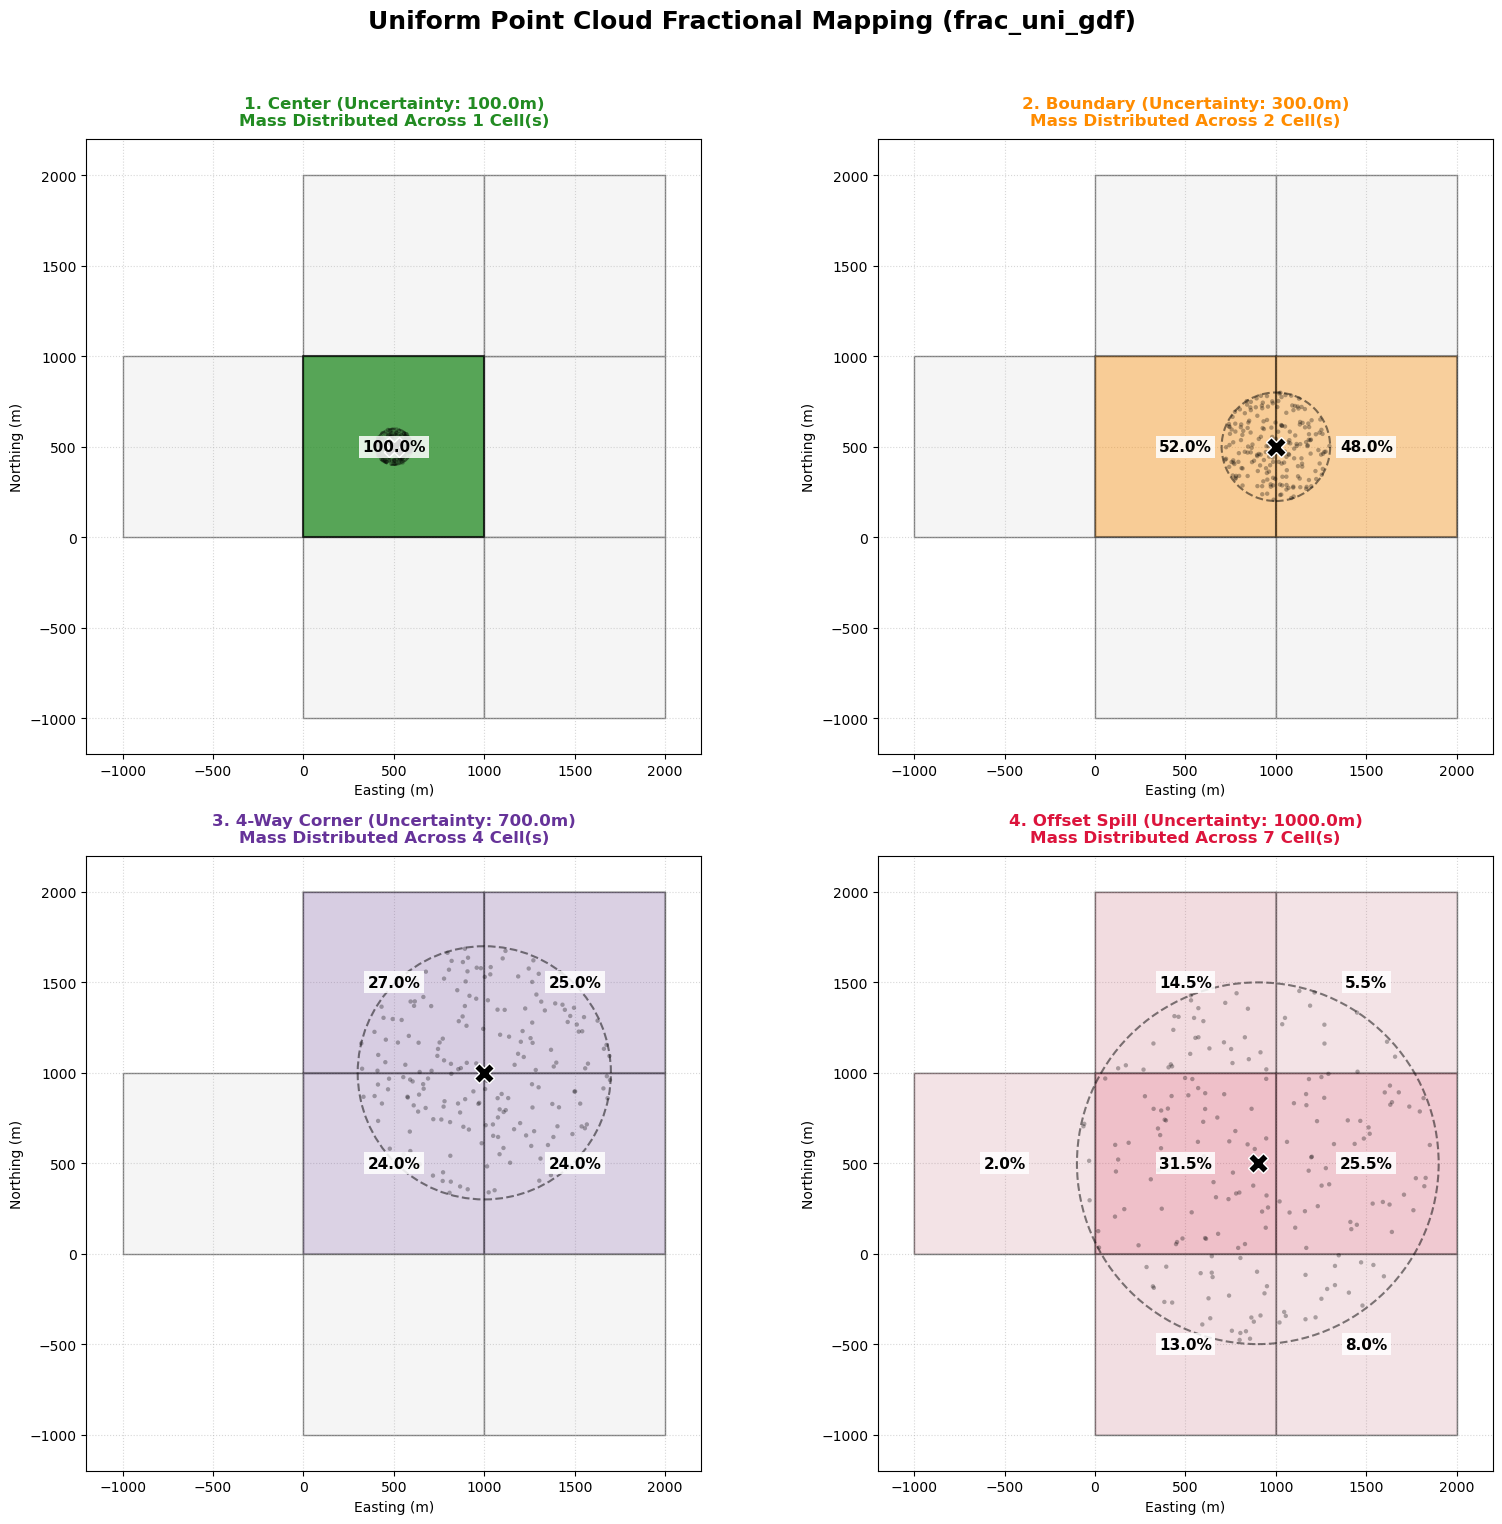

In [23]:
# =====================================================================
# 1. DEFINE FULL TEMPLATE GRID (Primary 2x2 + Extended Spillover Cells)
# =====================================================================
grid_definitions = {
    21994000: Polygon([(0, 0), (1000, 0), (1000, 1000), (0, 1000)]),          # Main Bottom-Left
    21994001: Polygon([(1000, 0), (2000, 0), (2000, 1000), (1000, 1000)]),    # Main Bottom-Right
    21990000: Polygon([(0, 1000), (1000, 1000), (1000, 2000), (0, 2000)]),     # Main Top-Left
    21990001: Polygon([(1000, 1000), (2000, 1000), (2000, 2000), (1000, 2000)]),# Main Top-Right
    21993999: Polygon([(-1000, 0), (0, 0), (0, 1000), (-1000, 1000)]),        # West Cell
    21998000: Polygon([(0, -1000), (1000, -1000), (1000, 0), (0, 0)]),        # South Bottom-Left
    21998001: Polygon([(1000, -1000), (2000, -1000), (2000, 0), (1000, 0)]),  # South Bottom-Right
}

grid_gdf = gpd.GeoDataFrame(
    {'grid_idx': list(grid_definitions.keys())},
    geometry=list(grid_definitions.values()),
    crs="EPSG:3035"
)

# Coordinates for origin centroids
obs_coords = {
    "1. Center": (500, 500),
    "2. Boundary": (1000, 500),
    "3. 4-Way Corner": (1000, 1000),
    "4. Offset Spill": (900, 500)
}

# =====================================================================
# 2. VISUALIZATION CODE (4-Panel Heatmap)
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()
plt.suptitle("Uniform Point Cloud Fractional Mapping (frac_uni_gdf)", fontsize=18, fontweight='bold', y=0.95)

colors = ['forestgreen', 'darkorange', 'rebeccapurple', 'crimson']
unique_obs = frac_uni_gdf['obs_id'].unique()

for idx, obs_name in enumerate(unique_obs):
    ax = axes[idx]
    color = colors[idx]
    
    # Filter fractional dataset for current observation
    obs_data = frac_uni_gdf[frac_uni_gdf['obs_id'] == obs_name]
    
    # Set viewport to encompass main grid and extended spillover cells
    ax.set_aspect('equal')
    ax.set_xlim(-1200, 2200)
    ax.set_ylim(-1200, 2200)
    
    # 1. Base Grid Outline
    grid_gdf.plot(ax=ax, facecolor='whitesmoke', edgecolor='gray', linewidth=1.0, zorder=1)
    
    # 2. Highlight cells with opacity driven by the fraction value
    for _, frac_row in obs_data.iterrows():
        cell = grid_gdf[grid_gdf['grid_idx'].astype(str) == str(frac_row['grid_idx'])]
        if not cell.empty:
            f_val = frac_row['fraction']
            # Scale fill opacity (alpha) proportionally to fraction value
            alpha_val = max(f_val * 0.75, 0.08)
            
            # Fill cell
            cell.plot(ax=ax, facecolor=color, alpha=alpha_val, edgecolor='black', linewidth=1.5, zorder=2)
            
            # Label percentage text inside cell centroid
            centroid = cell.geometry.centroid.iloc[0]
            ax.text(
                centroid.x, centroid.y, f"{f_val * 100:.1f}%", 
                ha='center', va='center', fontweight='bold', fontsize=11,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=2.5), zorder=6
            )
            
    # 3. Scatter original point cloud (if clouds_uni_gdf is in memory)
    ox, oy = obs_coords.get(obs_name, (500, 500))
    uncert = obs_data['uncertainty'].iloc[0]

    if 'clouds_uni_gdf' in globals():
        orig_match = clouds_uni_gdf[clouds_uni_gdf['obs_id'] == obs_name]
        if not orig_match.empty and 'point_cloud' in orig_match.columns:
            mp = orig_match.iloc[0]['point_cloud']
            if mp is not None:
                cloud_x = [pt.x for pt in mp.geoms]
                cloud_y = [pt.y for pt in mp.geoms]
                ax.scatter(cloud_x, cloud_y, color='black', alpha=0.3, s=10, edgecolor='none', zorder=4)
    else:
        # Fallback disk sample visualization
        np.random.seed(42 + idx)
        r = uncert * np.sqrt(np.random.uniform(0, 1, 150))
        theta = np.random.uniform(0, 2 * np.pi, 150)
        ax.scatter(ox + r * np.cos(theta), oy + r * np.sin(theta), color='black', alpha=0.3, s=10, edgecolor='none', zorder=4)

    # 4. Plot Origin Centroid Marker & Uncertainty Boundary Radius
    ax.plot(ox, oy, marker='X', color='black', markersize=14, markeredgecolor='white', zorder=5)
    circle = plt.Circle((ox, oy), uncert, color='black', fill=False, linestyle='--', alpha=0.5, linewidth=1.5, zorder=3)
    ax.add_patch(circle)

    # Formatting
    ax.set_title(f"{obs_name} (Uncertainty: {uncert}m)\nMass Distributed Across {len(obs_data)} Cell(s)", 
                 fontweight='bold', color=color, pad=10)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax.set_xticks(np.arange(-1000, 2001, 500))
    ax.set_yticks(np.arange(-1000, 2001, 500))
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Polygon to template fractional weight calculation

Areal features like lakes, historical borders, or protected areas require complex fracturing when converted to a grid. The `map_polygon_to_template` method maps polygon datasets by perfectly fracturing and distributing intersection weights onto a strict grid blueprint. 
*   It executes a batched intersection (shattering) of the source polygons against the target grid.
*   It calculates fractional yields (such as `areal_fraction`), measuring the new intersected fragment's area against the original pre-intersect baseline area. 
*   It inherently tracks the original source geometry mappings and centroids to support downstream mass-conservation QA/QC constraints.

In [41]:
# Map polygonal buffer geometries to template grid (Area Fraction Overlap)
frac_poly_gdf = engine.map_polygon_to_template(
    source_gdf=polygons_gdf,
    target_grid_name="EEA_1km",
    geom_column="geometry",       # Column holding the Polygon geometries
    output_col="grid_idx"
)

# Display the long-format fractional table
frac_poly_gdf

,grid_idx,src_uid,centroid_grid_idx,areal_fraction,obs_id,uncertainty
0,21994000,0,21994000,1.000000,1. Center,100.0
1,21994000,1,21994001,0.500000,2. Boundary,300.0
2,21994001,1,21994001,0.500000,2. Boundary,300.0
3,21990000,2,21990001,0.250000,3. 4-Way Corner,700.0
4,21990001,2,21990001,0.250000,3. 4-Way Corner,700.0
5,21994000,2,21990001,0.250000,3. 4-Way Corner,700.0
6,21994001,2,21990001,0.250000,3. 4-Way Corner,700.0
7,21990000,3,21994000,0.113501,4. Offset Spill,1000.0
8,21990001,3,21994000,0.081775,4. Offset Spill,1000.0
9,21993999,3,21994000,0.018491,4. Offset Spill,1000.0


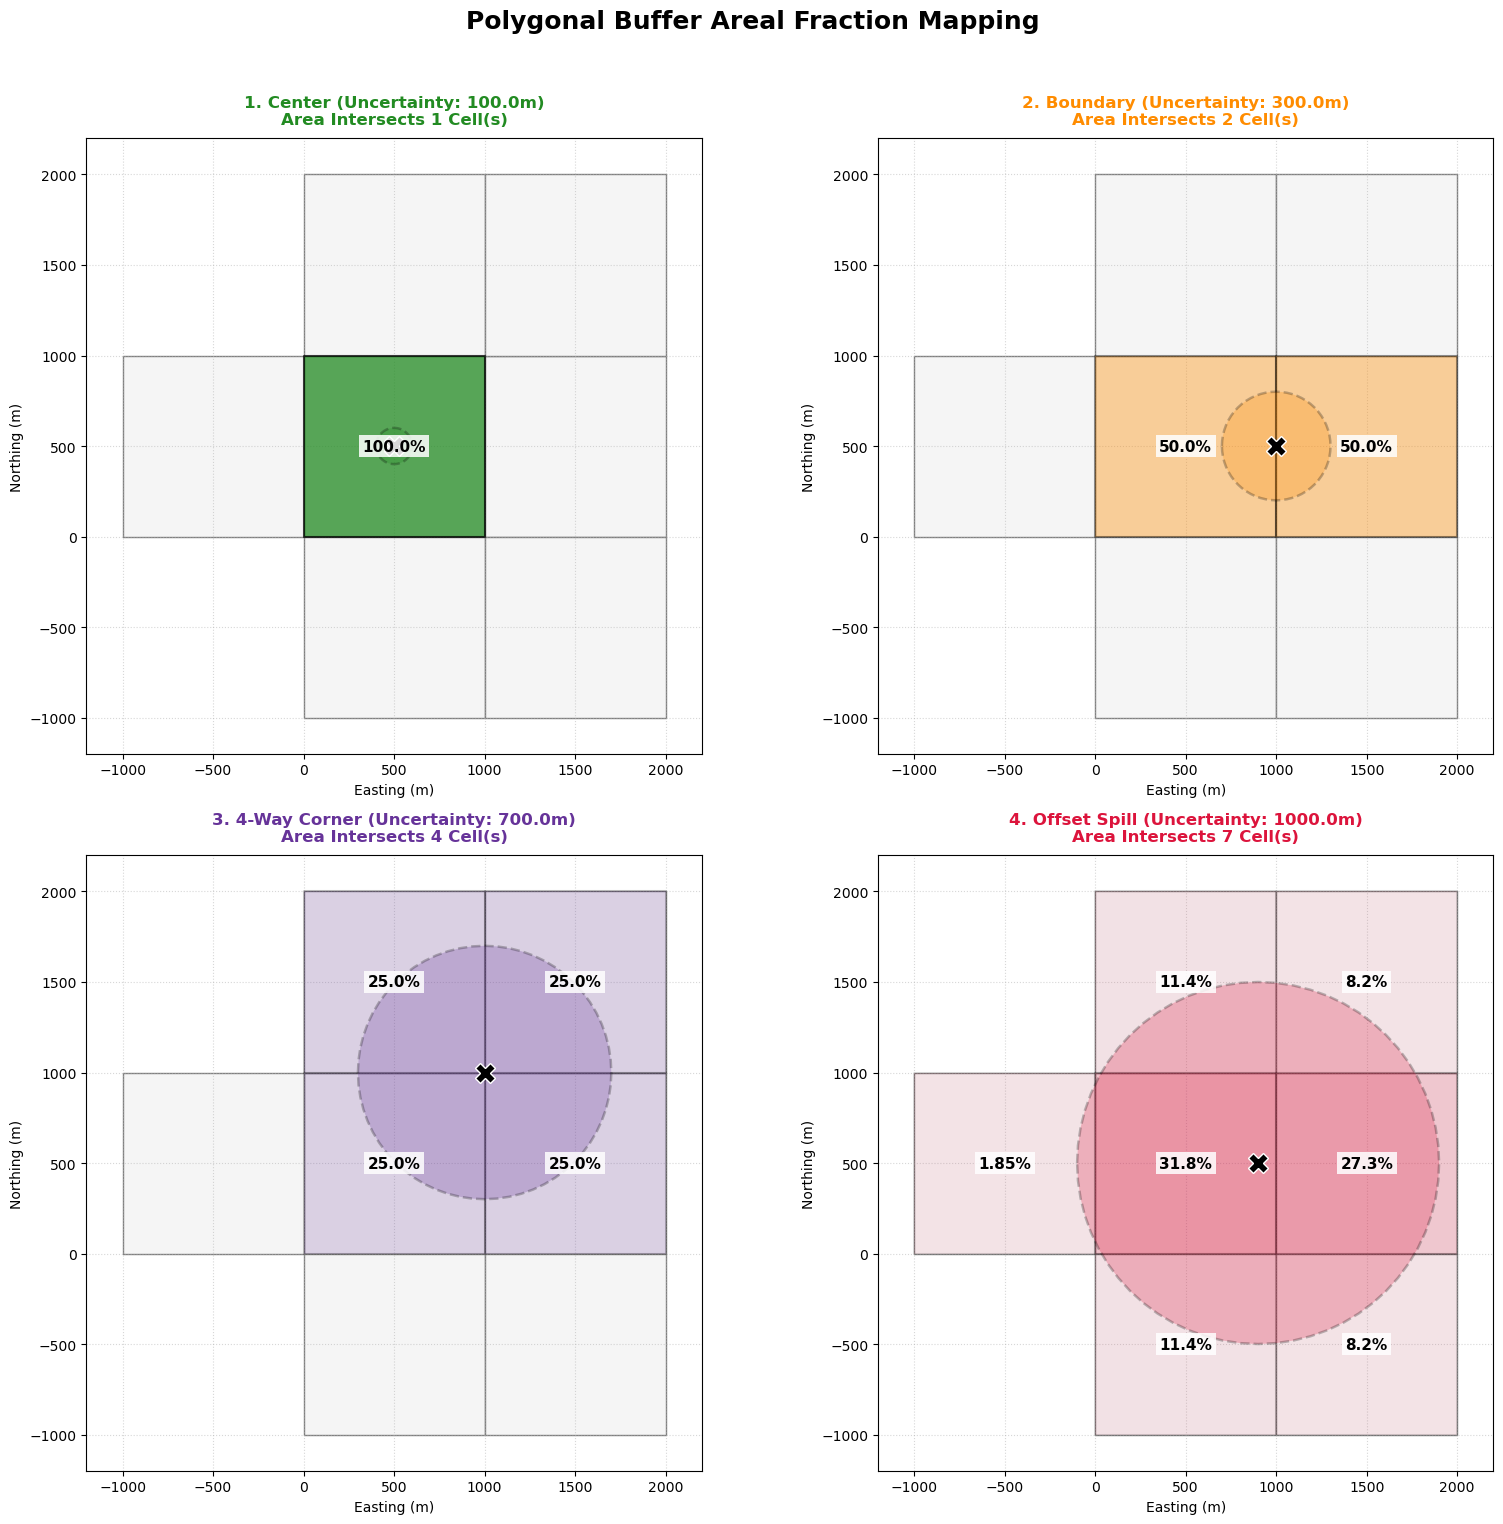

In [43]:
# =====================================================================
# 1. DEFINE FULL TEMPLATE GRID (Primary 2x2 + Neighbor Spillover Mesh)
# =====================================================================
grid_definitions = {
    21994000: Polygon([(0, 0), (1000, 0), (1000, 1000), (0, 1000)]),          # Main Bottom-Left
    21994001: Polygon([(1000, 0), (2000, 0), (2000, 1000), (1000, 1000)]),    # Main Bottom-Right
    21990000: Polygon([(0, 1000), (1000, 1000), (1000, 2000), (0, 2000)]),     # Main Top-Left
    21990001: Polygon([(1000, 1000), (2000, 1000), (2000, 2000), (1000, 2000)]),# Main Top-Right
    21993999: Polygon([(-1000, 0), (0, 0), (0, 1000), (-1000, 1000)]),        # West Cell
    21998000: Polygon([(0, -1000), (1000, -1000), (1000, 0), (0, 0)]),        # South Bottom-Left
    21998001: Polygon([(1000, -1000), (2000, -1000), (2000, 0), (1000, 0)]),  # South Bottom-Right
}

grid_gdf = gpd.GeoDataFrame(
    {'grid_idx': list(grid_definitions.keys())},
    geometry=list(grid_definitions.values()),
    crs="EPSG:3035"
)

# Centroid positions for original observation points
obs_coords = {
    "1. Center": (500, 500),
    "2. Boundary": (1000, 500),
    "3. 4-Way Corner": (1000, 1000),
    "4. Offset Spill": (900, 500)
}

# =====================================================================
# 2. VISUALIZATION CODE (Consumes your DataFrame: poly_frac_df)
# =====================================================================
# Rename your variable here if needed:
df_to_plot = frac_poly_gdf  # <--- Change to your DataFrame variable name

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()
plt.suptitle("Polygonal Buffer Areal Fraction Mapping", fontsize=18, fontweight='bold', y=0.95)

colors = ['forestgreen', 'darkorange', 'rebeccapurple', 'crimson']
unique_obs = df_to_plot['obs_id'].unique()

for idx, obs_name in enumerate(unique_obs):
    ax = axes[idx]
    color = colors[idx]
    
    # Filter dataset for current observation
    obs_data = df_to_plot[df_to_plot['obs_id'] == obs_name]
    
    # Set viewport bounds to comfortably show main grid and spillover cells
    ax.set_aspect('equal')
    ax.set_xlim(-1200, 2200)
    ax.set_ylim(-1200, 2200)
    
    # 1. Base Grid Outline
    grid_gdf.plot(ax=ax, facecolor='whitesmoke', edgecolor='gray', linewidth=1.0, zorder=1)
    
    # 2. Highlight cells with opacity (alpha) driven by areal_fraction
    for _, frac_row in obs_data.iterrows():
        cell = grid_gdf[grid_gdf['grid_idx'].astype(str) == str(frac_row['grid_idx'])]
        if not cell.empty:
            f_val = frac_row['areal_fraction']
            # Alpha proportional to area fraction (min visibility threshold 0.08)
            alpha_val = max(f_val * 0.75, 0.08)
            
            # Fill cell
            cell.plot(ax=ax, facecolor=color, alpha=alpha_val, edgecolor='black', linewidth=1.5, zorder=2)
            
            # Label percentage text inside cell centroid
            centroid = cell.geometry.centroid.iloc[0]
            label_text = f"{f_val * 100:.1f}%" if f_val >= 0.05 else f"{f_val * 100:.2f}%"
            ax.text(
                centroid.x, centroid.y, label_text, 
                ha='center', va='center', fontweight='bold', fontsize=11,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=2.5), zorder=6
            )
            
    # 3. Plot Original Centroid & Buffer Polygon Boundary
    ox, oy = obs_coords.get(obs_name, (500, 500))
    uncert = obs_data['uncertainty'].iloc[0]
    
    # Draw original observation centroid marker ('X')
    ax.plot(ox, oy, marker='X', color='black', markersize=14, markeredgecolor='white', zorder=5)

    # Plot actual buffer geometry from polygons_gdf (if present in memory)
    if 'polygons_gdf' in globals():
        orig_match = polygons_gdf[polygons_gdf['obs_id'] == obs_name]
        if not orig_match.empty:
            poly_geom = orig_match.iloc[0].geometry
            gpd.GeoSeries([poly_geom]).plot(
                ax=ax, facecolor=color, edgecolor='black', 
                linewidth=1.8, linestyle='--', alpha=0.25, zorder=4
            )
    else:
        # Fallback circle geometry buffer outline
        circle = plt.Circle((ox, oy), uncert, color='black', fill=False, linestyle='--', alpha=0.5, linewidth=1.5, zorder=4)
        ax.add_patch(circle)

    # Formatting
    ax.set_title(
        f"{obs_name} (Uncertainty: {uncert}m)\nArea Intersects {len(obs_data)} Cell(s)", 
        fontweight='bold', color=color, pad=10
    )
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax.set_xticks(np.arange(-1000, 2001, 500))
    ax.set_yticks(np.arange(-1000, 2001, 500))
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()